# GROUP 11 - SET 11

In [129]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import pandas as pd
import numpy as np
import os
import glob
from datetime import datetime

In [2]:
# ==============================
# 2. CONFIGURATION
# ==============================

RUNS_DIRECTORY = "../data/runs"

qrels_file = "../data/qrels.trec8.adhoc"

OUTPUT_FOLDER = "../data/output"

FILE_PATTERN = "input.*"

DOC_THRESHOLD = 1000

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

## 1.0 Data Cleaning

In [3]:
def read_clean_trec(file_path):
    column_names = ["query_id", "Q0", "doc_id", "rank", "score", "system_name"]

    try:
        df = pd.read_csv(
            file_path,
            sep=r'\s+',
            engine='python',
            names=column_names,
            dtype=str
        )
    except Exception as e:
        print(f"ERROR reading {file_path}: {e}")
        return pd.DataFrame()

    df["rank"] = pd.to_numeric(df["rank"], errors="coerce")
    df["score"] = pd.to_numeric(df["score"], errors="coerce")

    df = df.drop(columns=["Q0"])

    df = df.dropna(
        subset=["query_id", "doc_id", "rank", "score", "system_name"]
    ).copy()

    # Rebuild rank based on score descending
    df = df.sort_values(
        ["query_id", "score"],
        ascending=[True, False]
    ).copy()

    df["rank"] = df.groupby("query_id").cumcount() + 1
    df["rank"] = df["rank"].astype(int)

    return df

In [4]:
# ==============================
# 4. LOAD ALL RUN FILES
# ==============================

def load_all_runs(directory, pattern):
    file_paths = glob.glob(os.path.join(directory, pattern))

    if not file_paths:
        raise ValueError("No files found in the specified directory.")

    print(f"Found {len(file_paths)} files. Loading...")

    dataframes = []

    for file_path in file_paths:
        df = read_clean_trec(file_path)

        if not df.empty:
            dataframes.append(df)
            print(f"Loaded: {os.path.basename(file_path)} | rows: {len(df)}")
        else:
            print(f"Skipped empty/error file: {os.path.basename(file_path)}")

    clean_data = pd.concat(dataframes, ignore_index=True)

    clean_data = clean_data.sort_values(
        by=["system_name", "query_id", "rank"],
        ascending=[True, True, True]
    ).copy()

    return clean_data

In [5]:
# ==============================
# 5. RUN BASIC CLEANING
# ==============================

print(f"Attempting to load files from: {RUNS_DIRECTORY}")
if not os.path.exists(RUNS_DIRECTORY):
    print(f"Error: The directory {RUNS_DIRECTORY} does not exist.")
else:
    files_in_dir = os.listdir(RUNS_DIRECTORY)
    print(f"Files found in directory {RUNS_DIRECTORY}: {files_in_dir}")
    if not files_in_dir:
        print(f"Warning: The directory {RUNS_DIRECTORY} is empty.")

clean_data = load_all_runs(RUNS_DIRECTORY, FILE_PATTERN)

print("\nTotal cleaned rows:", len(clean_data))
display(clean_data.head())

Attempting to load files from: ../data/runs
Files found in directory ../data/runs: ['input.Mer8Adtd2', 'input.ibms99b', 'input.CL99XT', 'input.fub99a', 'input.apl8c621', 'input.acsys8alo', 'input.pir9Attd', 'input.Dm8TFidf', 'input.INQ601', 'input.nttd8ale', 'input.GE8ATDN2', 'input.acsys8alo2', 'input.ok8asxc', 'input.att99atde', 'input.apl8ctd']
Found 15 files. Loading...
Loaded: input.Mer8Adtd2 | rows: 50000
Loaded: input.ibms99b | rows: 50000
Loaded: input.CL99XT | rows: 50000
Loaded: input.fub99a | rows: 50000
Loaded: input.apl8c621 | rows: 50000
Loaded: input.acsys8alo | rows: 50000
Loaded: input.pir9Attd | rows: 50000
Loaded: input.Dm8TFidf | rows: 50000
Loaded: input.INQ601 | rows: 50000
Loaded: input.nttd8ale | rows: 50000
Loaded: input.GE8ATDN2 | rows: 50000
Loaded: input.acsys8alo2 | rows: 50000
Loaded: input.ok8asxc | rows: 50000
Loaded: input.att99atde | rows: 50000
Loaded: input.apl8ctd | rows: 50000

Total cleaned rows: 750000


,query_id,doc_id,rank,score,system_name
100000,401,FT932-15086,1,11173.180,CL99XT
100001,401,FT944-6909,2,10887.392,CL99XT
100002,401,FT943-15609,3,10854.055,CL99XT
100003,401,FT924-7265,4,10381.393,CL99XT
100004,401,FBIS4-67877,5,562.130,CL99XT


In [6]:
# ==============================
# 6. BASIC VALIDATION
# ==============================

print("Data types:")
print(clean_data.dtypes)

print("\nMissing values:")
print(clean_data.isna().sum())

print("\nRank start check:")
print(clean_data.groupby(["system_name", "query_id"])["rank"].min().value_counts())

Data types:
query_id           str
doc_id             str
rank             int64
score          float64
system_name        str
dtype: object

Missing values:
query_id       0
doc_id         0
rank           0
score          0
system_name    0
dtype: int64

Rank start check:
rank
1    750
Name: count, dtype: int64


In [7]:
# ==============================
# 7. CHECK DUPLICATES
# ==============================

duplicates = clean_data.duplicated(
    subset=["system_name", "query_id", "doc_id"]
)

if duplicates.any():
    print("WARNING: Duplicate documents detected.")
    display(clean_data[duplicates].head())
else:
    print("OK: No duplicate documents found.")

OK: No duplicate documents found.


In [8]:
# ==============================
# 8. CHECK DOCUMENT COUNT PER ENTRY
# ==============================

query_doc_counts = (
    clean_data.groupby(["system_name", "query_id"])
    .size()
    .reset_index(name="doc_count")
)

display(query_doc_counts.head())

insufficient_queries = query_doc_counts[query_doc_counts["doc_count"] < DOC_THRESHOLD]

if not insufficient_queries.empty:
    print("WARNING: Some system-query pairs have fewer than 1000 documents.")
    display(insufficient_queries)
else:
    print("OK: All system-query pairs have enough documents.")

,system_name,query_id,doc_count
0,CL99XT,401,1000
1,CL99XT,402,1000
2,CL99XT,403,1000
3,CL99XT,404,1000
4,CL99XT,405,1000


OK: All system-query pairs have enough documents.


In [9]:
# ==============================
# 10. LOAD QRELS FILE
# ==============================

qrels_df = pd.read_csv(
    qrels_file,
    sep=r'\s+',
    header=None,
    names=["query_id", "ignore", "doc_id", "relevance"]
)

qrels_df.drop(columns=["ignore"], inplace=True)

print("Qrels loaded:", len(qrels_df), "rows")
display(qrels_df.head())

Qrels loaded: 86830 rows


,query_id,doc_id,relevance
0,401,FBIS3-10009,0
1,401,FBIS3-10059,0
2,401,FBIS3-10142,0
3,401,FBIS3-1026,0
4,401,FBIS3-10502,0


In [10]:
# ==============================
# 11. MATCH DATA TYPES BEFORE MERGING LATER
# ==============================

clean_data["query_id"] = clean_data["query_id"].astype(str)
clean_data["doc_id"] = clean_data["doc_id"].astype(str)

qrels_df["query_id"] = qrels_df["query_id"].astype(str)
qrels_df["doc_id"] = qrels_df["doc_id"].astype(str)
qrels_df["relevance"] = pd.to_numeric(qrels_df["relevance"], errors="coerce").fillna(0).astype(int)
# Convert any graded relevance (like 2) down to 1 to ensure binary relevance
qrels_df.loc[qrels_df["relevance"] > 1, "relevance"] = 1

In [11]:
# ==============================
# 12. EXPORT BASIC CLEAN DATA
# ==============================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

clean_file = os.path.join(OUTPUT_FOLDER, f"clean_runs_{timestamp}.csv")

clean_data.to_csv(clean_file, index=False)

print("Exported clean data:")
print(clean_file)

Exported clean data:
../data/output/clean_runs_20260620_151411.csv


### 1.1 Preparation for Analysis

In [12]:
## merge
merged_df = pd.merge(
    clean_data,
    qrels_df,
    on=['query_id', 'doc_id'],
    how='left'
)

merged_df['relevance'] = merged_df['relevance'].fillna(0).astype(int)

print(merged_df.head())

  query_id       doc_id  rank      score system_name  relevance
0      401  FT932-15086     1  11173.180      CL99XT          1
1      401   FT944-6909     2  10887.392      CL99XT          1
2      401  FT943-15609     3  10854.055      CL99XT          0
3      401   FT924-7265     4  10381.393      CL99XT          0
4      401  FBIS4-67877     5    562.130      CL99XT          0


In [13]:
## handle missing relevance
## document not in qrel = not relevant

print("Relevance distribution:")
print(merged_df['relevance'].value_counts())

print("\nMissing relevance:")
print(merged_df['relevance'].isna().sum())

print("\nCheck at least one relevant per query:")
print(
    merged_df.groupby(['system_name','query_id'])['relevance'].sum().head()
)
merged_df['relevance'].isna().sum()


Relevance distribution:
relevance
0    704123
1     45877
Name: count, dtype: int64

Missing relevance:
0

Check at least one relevant per query:
system_name  query_id
CL99XT       401         172
             402          64
             403          21
             404         112
             405          35
Name: relevance, dtype: int64


np.int64(0)

In [14]:
## sort data properly
merged_df = merged_df.sort_values(
    ['system_name', 'query_id', 'rank']
).copy()

In [15]:
## quick validation
print("Check relevance distribution:")
print(merged_df['relevance'].value_counts())

print("\nCheck one query:")
display(merged_df[merged_df['query_id'] == '401'].head(10))

Check relevance distribution:
relevance
0    704123
1     45877
Name: count, dtype: int64

Check one query:


,query_id,doc_id,rank,score,system_name,relevance
0,401,FT932-15086,1,11173.180,CL99XT,1
1,401,FT944-6909,2,10887.392,CL99XT,1
2,401,FT943-15609,3,10854.055,CL99XT,0
3,401,FT924-7265,4,10381.393,CL99XT,0
4,401,FBIS4-67877,5,562.130,CL99XT,0
5,401,FBIS4-67533,6,542.709,CL99XT,0
6,401,FT934-9441,7,304.628,CL99XT,0
7,401,FT924-11400,8,286.923,CL99XT,1
8,401,FBIS3-18410,9,271.099,CL99XT,0
9,401,FT941-16483,10,264.945,CL99XT,0


## 2.0 Data Analysis


#### 2.1 Precision

##### Precision@10

In [16]:
## STEP 1: Precision@10 (per-topic)

def precision_at_10(group):
    # sort by score descending (as per your choice)
    group_sorted = group.sort_values(by='score', ascending=False).head(10)

    # compute precision@10
    return group_sorted['relevance'].sum() / 10

# compute per-topic P@10
p10_results = (
    merged_df
    .groupby(['system_name', 'query_id'])
    .apply(precision_at_10)
    .reset_index(name='P@10')
)

print("Per-topic Precision@10:")
display(p10_results.sample(15))

Per-topic Precision@10:


,system_name,query_id,P@10
716,pir9Attd,417,0.5
243,Mer8Adtd2,444,0.9
4,CL99XT,405,0.6
320,acsys8alo2,421,0.0
236,Mer8Adtd2,437,0.1
70,Dm8TFidf,421,0.0
30,CL99XT,431,0.9
738,pir9Attd,439,0.2
48,CL99XT,449,0.4
304,acsys8alo2,405,0.2


In [17]:
## STEP 2: Precision@10 (per-system)

avg_p10 = (
    p10_results
    .groupby('system_name')['P@10']
    .mean()
    .reset_index(name='Mean_P@10')
)

print("\nOverall Precision@10 per system:")

for _, row in avg_p10.iterrows():
    print(f"System: {row['system_name']} - Mean Precision@10: {row['Mean_P@10']:.4f}")


Overall Precision@10 per system:
System: CL99XT - Mean Precision@10: 0.6920
System: Dm8TFidf - Mean Precision@10: 0.3440
System: GE8ATDN2 - Mean Precision@10: 0.5120
System: INQ601 - Mean Precision@10: 0.4360
System: Mer8Adtd2 - Mean Precision@10: 0.4440
System: acsys8alo - Mean Precision@10: 0.5300
System: acsys8alo2 - Mean Precision@10: 0.4740
System: apl8c621 - Mean Precision@10: 0.5040
System: apl8ctd - Mean Precision@10: 0.4500
System: att99atde - Mean Precision@10: 0.5480
System: fub99a - Mean Precision@10: 0.5300
System: ibms99b - Mean Precision@10: 0.4600
System: nttd8ale - Mean Precision@10: 0.4940
System: ok8asxc - Mean Precision@10: 0.4880
System: pir9Attd - Mean Precision@10: 0.5080


##### Precision at k

In [18]:
k_values = [1, 10, 50, 500, 1000]

def precision_at_k(group, k):
    # Sort by score descending and take top k
    group_sorted = group.sort_values(by='score', ascending=False).head(k)
    # Safely handle graded relevance (>0) and divide by k
    relevant_count = (group_sorted['relevance'] > 0).sum()
    return relevant_count / k

precision_results = {}
avg_precision_results = {}
precision_matrix_results = {}

# Ensure the output folder exists
os.makedirs(f"{OUTPUT_FOLDER}/PRECISION", exist_ok=True)

for k in k_values:
    # 1. Per system-per query Precision@k
    result = (
        merged_df
        .groupby(['system_name', 'query_id'])
        .apply(lambda x: precision_at_k(x, k))
        .reset_index(name=f'P@{k}')
    )
    precision_results[k] = result

    # 2. Average Precision@k per system (for summary table later)
    avg_result = (
        result
        .groupby('system_name')[f'P@{k}']
        .mean()
        .reset_index(name=f'Mean_P@{k}')
    )
    avg_precision_results[k] = avg_result

    # =========================================================
    # 3. FORMAT INTO PIVOT MATRIX (Like Image)
    # =========================================================

    # Pivot: Rows = query_id, Columns = system_name
    matrix_df = result.pivot(index='query_id', columns='system_name', values=f'P@{k}').reset_index()

    # Get just the system columns
    system_cols = [col for col in matrix_df.columns if col != 'query_id']

    # Add 'Overall' column (row-wise mean)
    matrix_df['Overall'] = matrix_df[system_cols].mean(axis=1)

    # Calculate 'Overall' row (column-wise mean)
    overall_row = matrix_df[system_cols].mean().to_dict()
    overall_row['query_id'] = 'Overall'
    overall_row['Overall'] = matrix_df['Overall'].mean()

    # Append the Overall row to the bottom
    matrix_df = pd.concat([matrix_df, pd.DataFrame([overall_row])], ignore_index=True)

    # Save this specific matrix to Google Drive
    file_path = f"{OUTPUT_FOLDER}/PRECISION/precision_at_{k}_matrix.csv"
    matrix_df.to_csv(file_path, index=False)
    print(f"Saved Matrix: {file_path}")

    # Store for display
    precision_matrix_results[k] = matrix_df

Saved Matrix: ../data/output/PRECISION/precision_at_1_matrix.csv
Saved Matrix: ../data/output/PRECISION/precision_at_10_matrix.csv
Saved Matrix: ../data/output/PRECISION/precision_at_50_matrix.csv
Saved Matrix: ../data/output/PRECISION/precision_at_500_matrix.csv
Saved Matrix: ../data/output/PRECISION/precision_at_1000_matrix.csv


In [19]:
# DISPLAY AND SUMMARIZE RESULTS

# 1. Display the pivot matrix exactly like the picture (using k=10 as an example)
print("\n========== MATRIX FORMAT (Precision@10) ==========")
display(precision_matrix_results[10])

# 2. Combine Overall Precision scores into your final summary table
final_precision = avg_precision_results[k_values[0]]

for k in k_values[1:]:
    final_precision = pd.merge(
        final_precision,
        avg_precision_results[k],
        on='system_name'
    )

print("\n========== SUMMARY OVERALL PRECISION SCORES ==========")
display(final_precision.sample(15))

# 3. Save the summary file
summary_path = f"{OUTPUT_FOLDER}/PRECISION/overall_precision_all_k.csv"
final_precision.to_csv(summary_path, index=False)
print(f"\nSaved overall precision summary to: {summary_path}")


========== MATRIX FORMAT (Precision@10) ==========


,query_id,CL99XT,Dm8TFidf,GE8ATDN2,INQ601,Mer8Adtd2,acsys8alo,acsys8alo2,apl8c621,apl8ctd,att99atde,fub99a,ibms99b,nttd8ale,ok8asxc,pir9Attd,Overall
0,401,0.300,0.100,0.800,0.100,0.200,0.80,0.600,0.900,0.00,0.100,0.00,0.00,0.000,0.000,0.000,0.260000
1,402,0.700,0.600,0.800,0.300,0.600,0.90,0.800,0.900,0.80,0.800,0.70,0.20,0.700,0.700,0.300,0.653333
2,403,0.400,1.000,1.000,0.800,0.700,1.00,1.000,0.900,1.00,1.000,1.00,0.90,1.000,1.000,1.000,0.913333
3,404,0.600,0.500,0.500,0.200,0.400,0.30,0.400,0.400,0.40,0.400,0.50,0.20,0.200,0.300,0.500,0.386667
4,405,0.600,0.400,0.500,0.100,0.300,0.50,0.200,0.600,0.60,0.300,0.50,0.40,0.400,0.400,0.500,0.420000
5,406,0.600,0.200,0.300,0.300,0.400,0.60,0.400,0.600,0.60,0.600,0.50,0.50,0.400,0.600,0.500,0.473333
6,407,0.900,0.400,0.900,0.700,0.800,0.70,0.200,0.900,0.80,0.900,0.90,0.80,0.800,0.800,0.700,0.746667
7,408,0.800,0.500,0.300,0.200,0.400,0.00,0.200,0.200,0.30,0.300,0.30,0.30,0.500,0.400,0.400,0.340000
8,409,0.500,0.400,0.400,0.300,0.300,0.40,0.400,0.300,0.30,0.500,0.30,0.20,0.300,0.100,0.200,0.326667
9,410,1.000,1.000,1.000,1.000,1.000,1.00,1.000,1.000,1.00,1.000,1.00,1.00,1.000,1.000,1.000,1.000000



========== SUMMARY OVERALL PRECISION SCORES ==========


,system_name,Mean_P@1,Mean_P@10,Mean_P@50,Mean_P@500,Mean_P@1000
4,Mer8Adtd2,0.60,0.444,0.2788,0.09000,0.05662
5,acsys8alo,0.58,0.530,0.3452,0.11024,0.06624
7,apl8c621,0.66,0.504,0.3196,0.10988,0.06670
11,ibms99b,0.56,0.460,0.3192,0.10252,0.06302
1,Dm8TFidf,0.56,0.344,0.1992,0.06044,0.03844
0,CL99XT,0.74,0.692,0.4032,0.11728,0.06734
6,acsys8alo2,0.60,0.474,0.3168,0.10096,0.06160
14,pir9Attd,0.58,0.508,0.3456,0.11168,0.06684
3,INQ601,0.44,0.436,0.2896,0.08716,0.05402
2,GE8ATDN2,0.60,0.512,0.3200,0.10172,0.06136



Saved overall precision summary to: ../data/output/PRECISION/overall_precision_all_k.csv


In [20]:
# ==============================
# Create variable names needed for correlation analysis
# ==============================

p1_df = precision_matrix_results[1]
p10_df = precision_matrix_results[10]
p50_df = precision_matrix_results[50]
p500_df = precision_matrix_results[500]
p1000_df = precision_matrix_results[1000]

print("Precision DataFrames created:")
print("p1_df, p10_df, p50_df, p500_df, p1000_df")

Precision DataFrames created:
p1_df, p10_df, p50_df, p500_df, p1000_df


### 2.2 MAP

In [21]:
# MAP@K CALCULATION

# 1. Total relevant documents per query (from qrels)
total_rel_per_query = (
    qrels_df[qrels_df['relevance'] > 0]
    .groupby('query_id')
    .size()
    .to_dict()
)


In [22]:
# 2. Function to calculate AP at a specific depth 'k'
def average_precision_at_k(group, k):
    # Get the query_id to look up the true total relevant docs
    qid = group.name[1]
    total_relevant = total_rel_per_query.get(qid, 0)

    # If the dataset has no relevant docs for this query, score is 0
    if total_relevant == 0:
        return 0.0

    # Sort by score descending and take top k
    group_sorted = group.sort_values(by='score', ascending=False).head(k)

    relevant_count = 0
    precision_sum = 0

    # Fast loop using your itertuples method
    for i, row in enumerate(group_sorted.itertuples(), start=1):
        if row.relevance > 0:
            relevant_count += 1
            precision_sum += relevant_count / i

    # Divide by the TRUE total relevant, not the local amount!
    return precision_sum / total_relevant


ap_results = {}
map_results = {}
map_matrix_results = {}

# Create a folder to save the CSVs (optional, but keeps things clean)
os.makedirs(f"{OUTPUT_FOLDER}/MAP_Results", exist_ok=True)

for k in k_values:
    # 1. Calculate Per system-per query AP@k
    result = (
        merged_df
        .groupby(['system_name', 'query_id'])
        .apply(lambda x: average_precision_at_k(x, k))
        .reset_index(name=f'AP@{k}')
    )
    ap_results[k] = result

    # 2. Calculate MAP@k per system (for the summary table later)
    avg_map = (
        result
        .groupby('system_name')[f'AP@{k}']
        .mean()
        .reset_index(name=f'MAP@{k}')
    )
    map_results[k] = avg_map

    # Pivot the data: Rows = Topics (query_id), Columns = Systems
    matrix_df = result.pivot(index='query_id', columns='system_name', values=f'AP@{k}').reset_index()

    # Get a list of just the system columns
    system_cols = [col for col in matrix_df.columns if col != 'query_id']

    # Add 'Overall' column on the far right (Average of all systems for that topic)
    matrix_df['Overall'] = matrix_df[system_cols].mean(axis=1)

    # Calculate the 'Overall' row for the bottom (This is the MAP score for each system!)
    overall_row = matrix_df[system_cols].mean().to_dict()
    overall_row['query_id'] = 'Overall'
    overall_row['Overall'] = matrix_df['Overall'].mean() # Average of the averages

    # Append the Overall row to the bottom of the dataframe
    matrix_df = pd.concat([matrix_df, pd.DataFrame([overall_row])], ignore_index=True)

    # Save this beautiful matrix to a CSV file!
    file_path = f"{OUTPUT_FOLDER}/MAP_Results/MAP_at_{k}.csv"
    matrix_df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

    # Store it in our dictionary so we can look at it in notebook
    map_matrix_results[k] = matrix_df

    print(f"Calculated and saved matrix for MAP@{k}")

Saved: ../data/output/MAP_Results/MAP_at_1.csv
Calculated and saved matrix for MAP@1
Saved: ../data/output/MAP_Results/MAP_at_10.csv
Calculated and saved matrix for MAP@10
Saved: ../data/output/MAP_Results/MAP_at_50.csv
Calculated and saved matrix for MAP@50
Saved: ../data/output/MAP_Results/MAP_at_500.csv
Calculated and saved matrix for MAP@500
Saved: ../data/output/MAP_Results/MAP_at_1000.csv
Calculated and saved matrix for MAP@1000


In [23]:
# DISPLAY THE RESULTS

# Show the matrix for k=10 as an example of what was saved to CSV
print("\n========== EXAMPLE MATRIX FORMAT (MAP@10) ==========")
display(map_matrix_results[10])

# Keep your excellent summary merging code!
# This creates a table comparing MAP@1, MAP@10, etc., side-by-side
final_map_summary = map_results[k_values[0]]
for k in k_values[1:]:
    final_map_summary = pd.merge(
        final_map_summary,
        map_results[k],
        on='system_name'
    )

print("\n========== SUMMARY OVERALL MAP SCORES ==========")
display(final_map_summary)

# Optionally save the summary table too
final_map_summary.to_csv(
    f"{OUTPUT_FOLDER}/MAP_Results/overall_MAP_summary_all_k.csv",
    index=False
)


========== EXAMPLE MATRIX FORMAT (MAP@10) ==========


,query_id,CL99XT,Dm8TFidf,GE8ATDN2,INQ601,Mer8Adtd2,acsys8alo,acsys8alo2,apl8c621,apl8ctd,att99atde,fub99a,ibms99b,nttd8ale,ok8asxc,pir9Attd,Overall
0,401,0.007917,0.000417,0.023348,0.000333,0.004444,0.018751,0.012417,0.029667,0.000000,0.000417,0.000000,0.000000,0.000000,0.000000,0.000000,0.006514
1,402,0.082937,0.065312,0.091597,0.017188,0.059137,0.112500,0.094722,0.106513,0.086443,0.095263,0.079568,0.020833,0.065729,0.066845,0.020238,0.070988
2,403,0.129365,0.476190,0.476190,0.341213,0.226587,0.476190,0.476190,0.423810,0.476190,0.476190,0.476190,0.428571,0.476190,0.476190,0.476190,0.420763
3,404,0.025156,0.019855,0.028672,0.002934,0.013190,0.009859,0.018310,0.025822,0.020736,0.009859,0.027582,0.005164,0.008803,0.008979,0.013777,0.015913
4,405,0.141667,0.065476,0.074196,0.002924,0.029449,0.083041,0.023684,0.127412,0.135673,0.049342,0.074687,0.044904,0.058406,0.033469,0.076754,0.068072
5,406,0.312546,0.089744,0.128205,0.186813,0.195360,0.327350,0.225275,0.253571,0.319658,0.379304,0.262821,0.299359,0.218315,0.338889,0.281197,0.254560
6,407,0.132353,0.058824,0.130882,0.099673,0.098693,0.068575,0.017974,0.132353,0.103560,0.132353,0.129248,0.106886,0.112868,0.117647,0.093627,0.102368
7,408,0.065042,0.035381,0.012107,0.008475,0.024247,0.000000,0.003578,0.011299,0.008898,0.017302,0.025424,0.023305,0.026500,0.018738,0.011461,0.019450
8,409,0.134686,0.124242,0.080087,0.113636,0.098485,0.087879,0.116883,0.107955,0.125000,0.142136,0.077652,0.060606,0.087121,0.045455,0.090909,0.099515
9,410,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846,0.153846



========== SUMMARY OVERALL MAP SCORES ==========


,system_name,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000
0,CL99XT,0.018643,0.130851,0.254829,0.365231,0.373043
1,Dm8TFidf,0.013362,0.073952,0.123216,0.158051,0.163035
2,GE8ATDN2,0.016207,0.088222,0.162401,0.249442,0.257968
3,INQ601,0.011858,0.080583,0.157460,0.224815,0.232549
4,Mer8Adtd2,0.014656,0.077695,0.146641,0.214131,0.223131
5,acsys8alo,0.014283,0.101239,0.191688,0.283580,0.293502
6,acsys8alo2,0.016356,0.095007,0.174114,0.254326,0.263668
7,apl8c621,0.017370,0.105636,0.200697,0.302168,0.312633
8,apl8ctd,0.016495,0.091294,0.182511,0.277154,0.285989
9,att99atde,0.014879,0.099052,0.201852,0.307403,0.316549


In [24]:
# ==============================
# Create MAP variable names needed for correlation analysis
# ==============================

map1_df = map_matrix_results[1]
map10_df = map_matrix_results[10]
map50_df = map_matrix_results[50]
map500_df = map_matrix_results[500]
map1000_df = map_matrix_results[1000]

print("MAP DataFrames created:")
print("map1_df, map10_df, map50_df, map500_df, map1000_df")

MAP DataFrames created:
map1_df, map10_df, map50_df, map500_df, map1000_df


### 2.3 NDCG

In [25]:
# NDCG@K CALCULATION
import numpy as np
import os

# Function to calculate DCG at a specific depth 'k'
def dcg_at_k(relevance_scores, k):
    relevance_scores = np.asarray(relevance_scores)[:k]
    if relevance_scores.size == 0:
        return 0.0
    discounts = np.log2(np.arange(2, relevance_scores.size + 2))
    return np.sum(relevance_scores / discounts)

# Function to calculate NDCG at a specific depth 'k'
def ndcg_at_k(group, k):
    # Get the query_id to look up the true total relevant docs
    qid = group.name[1]
    total_relevant = total_rel_per_query.get(qid, 0)

    # If the dataset has no relevant docs for this query, score is 0
    if total_relevant == 0:
        return 0.0

    # Sort by score descending and take top k
    group_sorted = group.sort_values(by='score', ascending=False).head(k)
    actual_relevance = group_sorted["relevance"].values
    actual_dcg = dcg_at_k(actual_relevance, k)

    ideal_hits = min(total_relevant, k)
    ideal_relevance = np.ones(ideal_hits)
    ideal_dcg = dcg_at_k(ideal_relevance, k)

    # Divide by the TRUE ideal DCG
    if ideal_dcg == 0:
        return 0.0
    return actual_dcg / ideal_dcg

ndcg_results = {}
avg_ndcg_results = {}
ndcg_matrix_results = {}

# Create a folder to save the CSVs (optional, but keeps things clean)
os.makedirs(f"{OUTPUT_FOLDER}/NDCG_Results", exist_ok=True)

for k in k_values:
    # 1. Calculate Per system-per query NDCG@k
    result = (
        merged_df
        .groupby(["system_name", "query_id"])
        .apply(lambda x: ndcg_at_k(x, k))
        .reset_index(name=f"NDCG@{k}")
    )
    ndcg_results[k] = result

    # Calculate average per system for the summary later
    avg_ndcg = (
        result
        .groupby("system_name")[f"NDCG@{k}"]
        .mean()
        .reset_index(name=f"Mean_NDCG@{k}")
    )
    avg_ndcg_results[k] = avg_ndcg

    # Pivot the data: Rows = Topics (query_id), Columns = Systems
    matrix_df = result.pivot(index="query_id", columns="system_name", values=f"NDCG@{k}").reset_index()

    # Get a list of just the system columns
    system_cols = [col for col in matrix_df.columns if col != "query_id"]

    # Add 'Overall' column on the far right (Average of all systems for that topic)
    matrix_df["Overall"] = matrix_df[system_cols].mean(axis=1)

    # Calculate the 'Overall' row for the bottom (This is the NDCG score for each system!)
    overall_row = matrix_df[system_cols].mean().to_dict()
    overall_row["query_id"] = "Overall"
    overall_row["Overall"] = matrix_df["Overall"].mean() # Average of the averages

    # Append the Overall row to the bottom of the dataframe
    matrix_df = pd.concat([matrix_df, pd.DataFrame([overall_row])], ignore_index=True)

    # Save this beautiful matrix to a CSV file!
    file_path = f"{OUTPUT_FOLDER}/NDCG_Results/NDCG_at_{k}.csv"
    matrix_df.to_csv(file_path, index=False)
    print(f"Saved: {file_path}")

    # Store it in our dictionary so we can look at it in notebook
    ndcg_matrix_results[k] = matrix_df

    print(f"Calculated and saved matrix for NDCG@{k}")

Saved: ../data/output/NDCG_Results/NDCG_at_1.csv
Calculated and saved matrix for NDCG@1
Saved: ../data/output/NDCG_Results/NDCG_at_10.csv
Calculated and saved matrix for NDCG@10
Saved: ../data/output/NDCG_Results/NDCG_at_50.csv
Calculated and saved matrix for NDCG@50
Saved: ../data/output/NDCG_Results/NDCG_at_500.csv
Calculated and saved matrix for NDCG@500
Saved: ../data/output/NDCG_Results/NDCG_at_1000.csv
Calculated and saved matrix for NDCG@1000


In [26]:
# DISPLAY THE RESULTS

# Show the matrix for k=10 as an example of what was saved to CSV
print("\n========== EXAMPLE MATRIX FORMAT (NDCG@10) ==========")
display(ndcg_matrix_results[10])

# This creates a table comparing NDCG@1, NDCG@10, etc., side-by-side
final_ndcg_summary = avg_ndcg_results[k_values[0]]
for k in k_values[1:]:
    final_ndcg_summary = pd.merge(
        final_ndcg_summary,
        avg_ndcg_results[k],
        on='system_name'
    )

print("\n========== SUMMARY OVERALL NDCG SCORES ==========")
display(final_ndcg_summary)

# Optionally save the summary table too
final_ndcg_summary.to_csv(
    f"{OUTPUT_FOLDER}/NDCG_Results/overall_NDCG_summary_all_k.csv",
    index=False
)


========== EXAMPLE MATRIX FORMAT (NDCG@10) ==========


,query_id,CL99XT,Dm8TFidf,GE8ATDN2,INQ601,Mer8Adtd2,acsys8alo,acsys8alo2,apl8c621,apl8ctd,att99atde,fub99a,ibms99b,nttd8ale,ok8asxc,pir9Attd,Overall
0,401,0.428385,0.069431,0.826333,0.063621,0.298490,0.694765,0.548135,0.933746,0.000000,0.069431,0.000000,0.000000,0.000000,0.000000,0.000000,0.262156
1,402,0.788550,0.696840,0.848238,0.303082,0.665291,0.936379,0.857205,0.921602,0.823700,0.857981,0.775337,0.330138,0.721802,0.725735,0.359710,0.707439
2,403,0.428840,1.000000,1.000000,0.838957,0.677728,1.000000,1.000000,0.933746,1.000000,1.000000,1.000000,0.936379,1.000000,1.000000,1.000000,0.921043
3,404,0.543003,0.514186,0.605985,0.147829,0.373269,0.302404,0.469454,0.547398,0.503607,0.318319,0.595762,0.195189,0.289523,0.293437,0.376426,0.405053
4,405,0.701973,0.417061,0.514186,0.066254,0.278481,0.535709,0.224006,0.674571,0.693663,0.384311,0.471036,0.344452,0.440920,0.287448,0.476749,0.434055
5,406,0.621697,0.248908,0.327307,0.432318,0.469756,0.643404,0.501749,0.518465,0.636659,0.678504,0.557978,0.591927,0.488645,0.653049,0.579783,0.530010
6,407,0.936379,0.563788,0.933746,0.793584,0.816590,0.672693,0.286346,0.936379,0.836459,0.936379,0.930569,0.845426,0.860382,0.870125,0.778807,0.799843
7,408,0.860382,0.608317,0.307015,0.233651,0.491180,0.000000,0.151397,0.298490,0.271914,0.399569,0.469000,0.453743,0.532897,0.400306,0.313285,0.386076
8,409,0.476847,0.488829,0.360056,0.437352,0.408536,0.359409,0.466642,0.428385,0.453743,0.532897,0.367921,0.298490,0.343697,0.220092,0.358954,0.400123
9,410,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000



========== SUMMARY OVERALL NDCG SCORES ==========


,system_name,Mean_NDCG@1,Mean_NDCG@10,Mean_NDCG@50,Mean_NDCG@500,Mean_NDCG@1000
0,CL99XT,0.74,0.716428,0.569267,0.635339,0.671461
1,Dm8TFidf,0.56,0.385672,0.310467,0.363569,0.399003
2,GE8ATDN2,0.60,0.536085,0.434540,0.517872,0.561775
3,INQ601,0.44,0.447578,0.397585,0.466935,0.509582
4,Mer8Adtd2,0.60,0.480382,0.395043,0.477580,0.526250
5,acsys8alo,0.58,0.543947,0.468979,0.554467,0.601051
6,acsys8alo2,0.60,0.499038,0.438665,0.519811,0.566490
7,apl8c621,0.66,0.539067,0.458823,0.577955,0.624432
8,apl8ctd,0.56,0.476374,0.419386,0.546654,0.590040
9,att99atde,0.62,0.562190,0.483185,0.573058,0.615255


In [27]:
# ==============================
# Create nDCG variable names needed for correlation analysis
# ==============================

ndcg1_df = ndcg_matrix_results[1]
ndcg10_df = ndcg_matrix_results[10]
ndcg50_df = ndcg_matrix_results[50]
ndcg500_df = ndcg_matrix_results[500]
ndcg1000_df = ndcg_matrix_results[1000]

print("nDCG DataFrames created:")
print("ndcg1_df, ndcg10_df, ndcg50_df, ndcg500_df, ndcg1000_df")

nDCG DataFrames created:
ndcg1_df, ndcg10_df, ndcg50_df, ndcg500_df, ndcg1000_df


In [28]:
required_vars = [
    'p1_df', 'p10_df', 'p50_df', 'p500_df', 'p1000_df',
    'map1_df', 'map10_df', 'map50_df', 'map500_df', 'map1000_df',
    'ndcg1_df', 'ndcg10_df', 'ndcg50_df', 'ndcg500_df', 'ndcg1000_df'
]

for var in required_vars:
    print(var, "exists:", var in globals())

p1_df exists: True
p10_df exists: True
p50_df exists: True
p500_df exists: True
p1000_df exists: True
map1_df exists: True
map10_df exists: True
map50_df exists: True
map500_df exists: True
map1000_df exists: True
ndcg1_df exists: True
ndcg10_df exists: True
ndcg50_df exists: True
ndcg500_df exists: True
ndcg1000_df exists: True


## 3.0 Correlation Analysis


In [29]:
# ==============================================================
# Helper Functions 
# ==============================================================
 
from scipy.stats import spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
 
metric_source = {
    'P@1':    p1_df,
    'P@10':   p10_df,
    'P@50':   p50_df,
    'P@500':  p500_df,
    'P@1000': p1000_df,
 
    'MAP@1':    map1_df,
    'MAP@10':   map10_df,
    'MAP@50':   map50_df,
    'MAP@500':  map500_df,
    'MAP@1000': map1000_df,
 
    'nDCG@1':    ndcg1_df,
    'nDCG@10':   ndcg10_df,
    'nDCG@50':   ndcg50_df,
    'nDCG@500':  ndcg500_df,
    'nDCG@1000': ndcg1000_df,
}
 
def get_metric_scores(metric_name):
    """
    Get overall system scores for a given metric.
    Filters to the 'Overall' query row, drops the query_id column,
    removes the 'Overall' system row, and ensures numeric type.
    """
    df = metric_source[metric_name]
    scores = df[df['query_id'] == 'Overall'].drop(columns='query_id').squeeze()
    scores = scores.drop(index='Overall', errors='ignore')
    scores = pd.to_numeric(scores, errors='coerce')  # safety: ensure numeric
    return scores
 
def calculate_metric_block(base_metric, comparison_metrics):
    """
    Compute Spearman and Kendall Tau correlation
    for one base metric against a list of comparison metrics.
    Returns a DataFrame with both correlation values and p-values.
    """
    results = []
    base_scores = get_metric_scores(base_metric)
    for metric in comparison_metrics:
        comparison_scores = get_metric_scores(metric)
        spear_corr, spear_p = spearmanr(base_scores, comparison_scores)
        kend_corr,  kend_p  = kendalltau(base_scores, comparison_scores)
        results.append({
            'Metric Pair':      f"{base_metric} vs {metric}",
            'Spearman':         round(spear_corr, 6),
            'Spearman p-value': round(spear_p,    6),
            'Kendall Tau':      round(kend_corr,  6),
            'Kendall p-value':  round(kend_p,     6),
        })
    return pd.DataFrame(results)
 
def cross_metric_corr_matrix(row_metrics, col_metrics, method='spearman'):
    """
    Build a correlation matrix using either Spearman or Kendall Tau.
    method: 'spearman' or 'kendall'
    """
    corr_matrix = pd.DataFrame(index=row_metrics, columns=col_metrics, dtype=float)
    for row_metric in row_metrics:
        for col_metric in col_metrics:
            row_scores = get_metric_scores(row_metric)
            col_scores = get_metric_scores(col_metric)
            if method == 'kendall':
                corr, _ = kendalltau(row_scores, col_scores)
            else:
                corr, _ = spearmanr(row_scores, col_scores)
            corr_matrix.loc[row_metric, col_metric] = round(corr, 2)
    return corr_matrix
 
def plot_correlation_bar_dual(df, title):
    """
    Bar chart comparing Spearman and Kendall Tau side by side for each metric pair.
    y-axis is 0 to 1 (full correlation range).
    Blue = Spearman, Coral = Kendall Tau.
    """
    x = range(len(df))
    width = 0.35
    fig, ax = plt.subplots(figsize=(max(10, len(df) * 0.9), 5))
    ax.bar([i - width/2 for i in x], df['Spearman'],    width,
           label='Spearman',    color='steelblue')
    ax.bar([i + width/2 for i in x], df['Kendall Tau'], width,
           label='Kendall Tau', color='coral')
    ax.set_xticks(list(x))
    ax.set_xticklabels(df['Metric Pair'], rotation=45, ha='right')
    ax.set_ylim(0, 1)                              
    ax.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])
    ax.set_ylabel('Correlation')
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
 
def plot_dual_heatmap(spear_matrix, kend_matrix, title_prefix, xlabel, ylabel, figsize=(18, 6)):
    """
    Plot Spearman and Kendall Tau heatmaps side by side for easy comparison.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, matrix, method in zip(axes,
                                   [spear_matrix, kend_matrix],
                                   ['Spearman', 'Kendall Tau']):
        sns.heatmap(matrix, annot=True, cmap='coolwarm',
                    fmt='.2f', vmin=0, vmax=1, linewidths=0.5, ax=ax)
        ax.set_title(f"{method}: {title_prefix}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()
 
def plot_heatmap(corr_matrix, title, xlabel, ylabel, figsize=(8, 6)):
    """
    Original single heatmap function — kept for backward compatibility.
    """
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
                fmt='.2f', vmin=0, vmax=1, linewidths=0.5)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()
 

In [30]:
# ==============================================================
# Metric Preview Table
# ==============================================================
all_metric_preview = pd.DataFrame({
    'P@10':     get_metric_scores('P@10'),
    'MAP@10':   get_metric_scores('MAP@10'),
    'MAP@1000': get_metric_scores('MAP@1000'),
    'nDCG@10':  get_metric_scores('nDCG@10'),
})
display(all_metric_preview)
 

,P@10,MAP@10,MAP@1000,nDCG@10
CL99XT,0.692,0.130851,0.373043,0.716428
Dm8TFidf,0.344,0.073952,0.163035,0.385672
GE8ATDN2,0.512,0.088222,0.257968,0.536085
INQ601,0.436,0.080583,0.232549,0.447578
Mer8Adtd2,0.444,0.077695,0.223131,0.480382
acsys8alo,0.530,0.101239,0.293502,0.543947
acsys8alo2,0.474,0.095007,0.263668,0.499038
apl8c621,0.504,0.105636,0.312633,0.539067
apl8ctd,0.450,0.091294,0.285989,0.476374
att99atde,0.548,0.099052,0.316549,0.562190


In [31]:
# ==============================================================
# Column Definition
# ==============================================================
precision_cols  = ['P@1', 'P@10', 'P@50', 'P@500', 'P@1000']
map_cols        = ['MAP@1', 'MAP@10', 'MAP@50', 'MAP@500', 'MAP@1000']
ndcg_cols       = ['nDCG@1', 'nDCG@10', 'nDCG@50', 'nDCG@500', 'nDCG@1000']
all_metric_cols = precision_cols + map_cols + ndcg_cols
 

### 3.1 Compare Same Metric Across Depth

#### 3.1.1 Precision Across Depth

In [32]:
precision_comparison = pd.DataFrame({
    'P@1':    get_metric_scores('P@1'),
    'P@10':   get_metric_scores('P@10'),
    'P@50':   get_metric_scores('P@50'),
    'P@500':  get_metric_scores('P@500'),
    'P@1000': get_metric_scores('P@1000'),
})
precision_comparison = precision_comparison.drop(index='Overall', errors='ignore')
print(precision_comparison)

             P@1   P@10    P@50    P@500   P@1000
CL99XT      0.74  0.692  0.4032  0.11728  0.06734
Dm8TFidf    0.56  0.344  0.1992  0.06044  0.03844
GE8ATDN2    0.60  0.512  0.3200  0.10172  0.06136
INQ601      0.44  0.436  0.2896  0.08716  0.05402
Mer8Adtd2   0.60  0.444  0.2788  0.09000  0.05662
acsys8alo   0.58  0.530  0.3452  0.11024  0.06624
acsys8alo2  0.60  0.474  0.3168  0.10096  0.06160
apl8c621    0.66  0.504  0.3196  0.10988  0.06670
apl8ctd     0.56  0.450  0.2984  0.10260  0.06234
att99atde   0.62  0.548  0.3572  0.11004  0.06512
fub99a      0.70  0.530  0.3396  0.10880  0.06524
ibms99b     0.56  0.460  0.3192  0.10252  0.06302
nttd8ale    0.66  0.494  0.3276  0.10376  0.06240
ok8asxc     0.58  0.488  0.3220  0.10120  0.06026
pir9Attd    0.58  0.508  0.3456  0.11168  0.06684


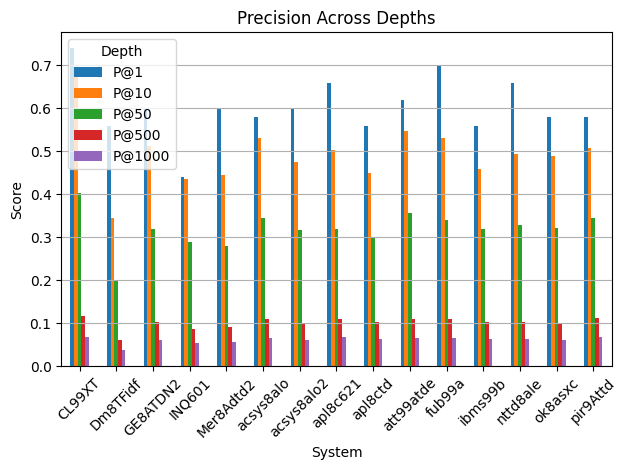

In [33]:
precision_comparison.plot(kind='bar')
plt.title('Precision Across Depths')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Depth')
plt.show()


Spearman: Precision @k


,P@1,P@10,P@50,P@500,P@1000
P@1,1.000000,0.707094,0.579986,0.527588,0.543850
P@10,0.707094,1.000000,0.934764,0.848973,0.784629
P@50,0.579986,0.934764,1.000000,0.885714,0.800000
P@500,0.527588,0.848973,0.885714,1.000000,0.960714
P@1000,0.543850,0.784629,0.800000,0.960714,1.000000



Kendall Tau: Precision @k


,P@1,P@10,P@50,P@500,P@1000
P@1,1.000000,0.563391,0.450564,0.370463,0.430539
P@10,0.563391,1.000000,0.822976,0.708142,0.612447
P@50,0.450564,0.822976,1.000000,0.733333,0.638095
P@500,0.370463,0.708142,0.733333,1.000000,0.866667
P@1000,0.430539,0.612447,0.638095,0.866667,1.000000


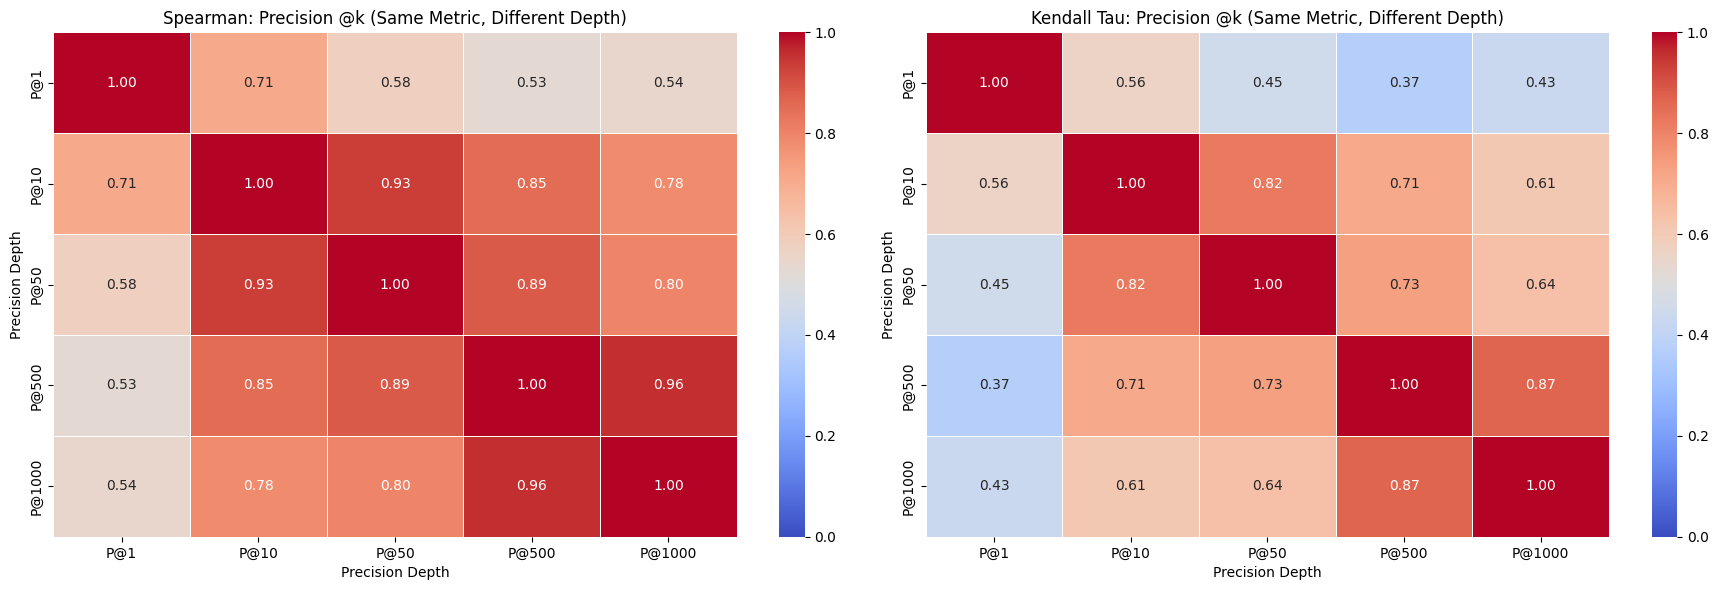

In [34]:
precision_depth_corr_spearman = precision_comparison.corr(method='spearman')
precision_depth_corr_kendall  = precision_comparison.corr(method='kendall')
print("\nSpearman: Precision @k")
display(precision_depth_corr_spearman)
print("\nKendall Tau: Precision @k")
display(precision_depth_corr_kendall)
plot_dual_heatmap(
    precision_depth_corr_spearman, precision_depth_corr_kendall,
    title_prefix="Precision @k (Same Metric, Different Depth)",
    xlabel="Precision Depth", ylabel="Precision Depth"
)

#### 3.1.2 MAP Across Depth

In [35]:
map_comparison = pd.DataFrame({
    'MAP@1':    get_metric_scores('MAP@1'),
    'MAP@10':   get_metric_scores('MAP@10'),
    'MAP@50':   get_metric_scores('MAP@50'),
    'MAP@500':  get_metric_scores('MAP@500'),
    'MAP@1000': get_metric_scores('MAP@1000'),
})
map_comparison = map_comparison.drop(index='Overall', errors='ignore')
print(map_comparison)
 

               MAP@1    MAP@10    MAP@50   MAP@500  MAP@1000
CL99XT      0.018643  0.130851  0.254829  0.365231  0.373043
Dm8TFidf    0.013362  0.073952  0.123216  0.158051  0.163035
GE8ATDN2    0.016207  0.088222  0.162401  0.249442  0.257968
INQ601      0.011858  0.080583  0.157460  0.224815  0.232549
Mer8Adtd2   0.014656  0.077695  0.146641  0.214131  0.223131
acsys8alo   0.014283  0.101239  0.191688  0.283580  0.293502
acsys8alo2  0.016356  0.095007  0.174114  0.254326  0.263668
apl8c621    0.017370  0.105636  0.200697  0.302168  0.312633
apl8ctd     0.016495  0.091294  0.182511  0.277154  0.285989
att99atde   0.014879  0.099052  0.201852  0.307403  0.316549
fub99a      0.018844  0.109134  0.198416  0.296584  0.306768
ibms99b     0.016415  0.086451  0.176557  0.268259  0.278388
nttd8ale    0.019208  0.101036  0.193072  0.282753  0.292138
ok8asxc     0.016912  0.096093  0.182632  0.270699  0.278696
pir9Attd    0.017008  0.102863  0.206589  0.310372  0.320659


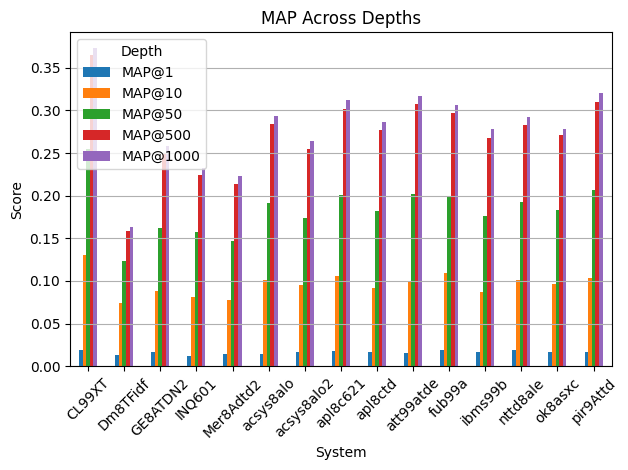

In [36]:
map_comparison.plot(kind='bar')
plt.title('MAP Across Depths')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Depth')
plt.show()


Spearman: MAP @k


,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000
MAP@1,1.000000,0.732143,0.685714,0.639286,0.639286
MAP@10,0.732143,1.000000,0.921429,0.917857,0.917857
MAP@50,0.685714,0.921429,1.000000,0.992857,0.992857
MAP@500,0.639286,0.917857,0.992857,1.000000,1.000000
MAP@1000,0.639286,0.917857,0.992857,1.000000,1.000000



Kendall Tau: MAP @k


,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000
MAP@1,1.000000,0.561905,0.542857,0.504762,0.504762
MAP@10,0.561905,1.000000,0.790476,0.790476,0.790476
MAP@50,0.542857,0.790476,1.000000,0.961905,0.961905
MAP@500,0.504762,0.790476,0.961905,1.000000,1.000000
MAP@1000,0.504762,0.790476,0.961905,1.000000,1.000000


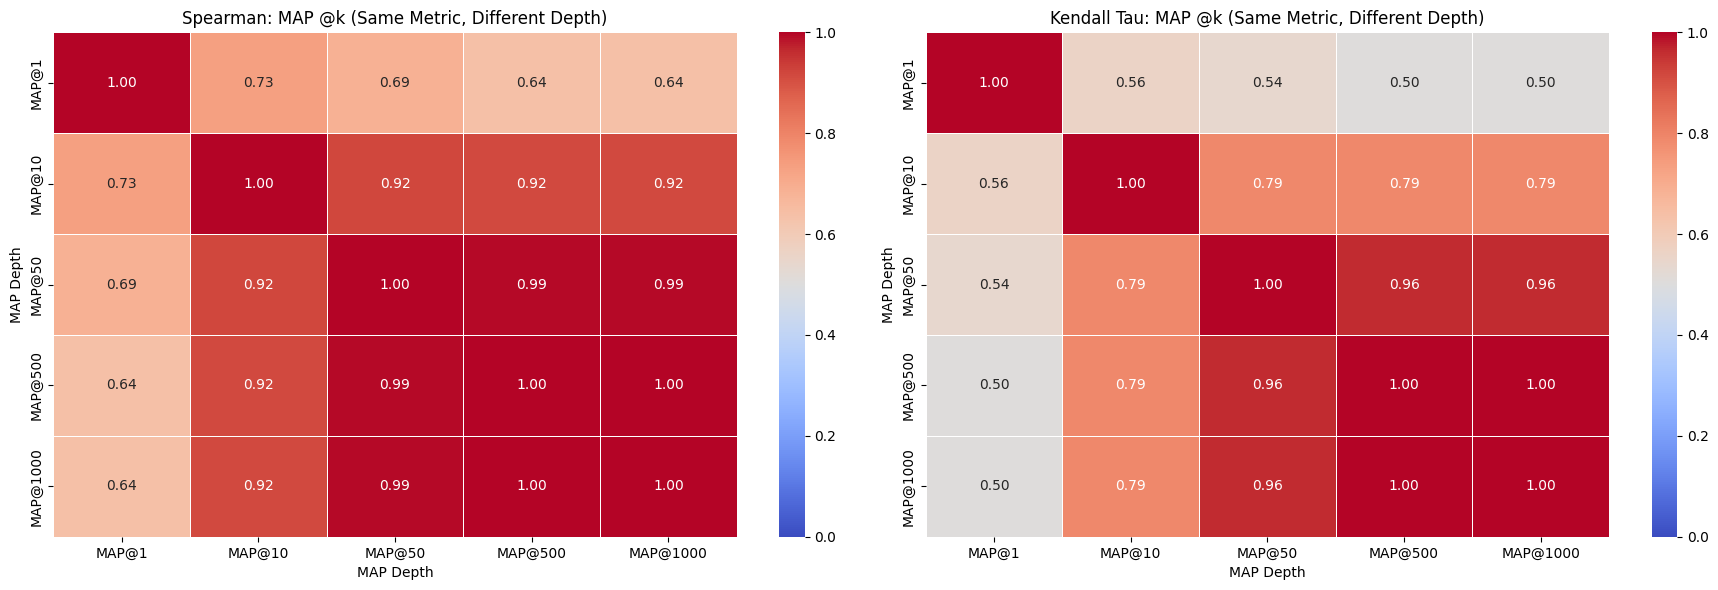

In [37]:
map_depth_corr_spearman = map_comparison.corr(method='spearman')
map_depth_corr_kendall  = map_comparison.corr(method='kendall')
print("\nSpearman: MAP @k")
display(map_depth_corr_spearman)
print("\nKendall Tau: MAP @k")
display(map_depth_corr_kendall)
plot_dual_heatmap(
    map_depth_corr_spearman, map_depth_corr_kendall,
    title_prefix="MAP @k (Same Metric, Different Depth)",
    xlabel="MAP Depth", ylabel="MAP Depth"
)

#### 3.1.3 NDCG Across Depth

In [38]:
ndcg_comparison = pd.DataFrame({
    'nDCG@1':    get_metric_scores('nDCG@1'),
    'nDCG@10':   get_metric_scores('nDCG@10'),
    'nDCG@50':   get_metric_scores('nDCG@50'),
    'nDCG@500':  get_metric_scores('nDCG@500'),
    'nDCG@1000': get_metric_scores('nDCG@1000'),
})
ndcg_comparison = ndcg_comparison.drop(index='Overall', errors='ignore')
print(ndcg_comparison)

            nDCG@1   nDCG@10   nDCG@50  nDCG@500  nDCG@1000
CL99XT        0.74  0.716428  0.569267  0.635339   0.671461
Dm8TFidf      0.56  0.385672  0.310467  0.363569   0.399003
GE8ATDN2      0.60  0.536085  0.434540  0.517872   0.561775
INQ601        0.44  0.447578  0.397585  0.466935   0.509582
Mer8Adtd2     0.60  0.480382  0.395043  0.477580   0.526250
acsys8alo     0.58  0.543947  0.468979  0.554467   0.601051
acsys8alo2    0.60  0.499038  0.438665  0.519811   0.566490
apl8c621      0.66  0.539067  0.458823  0.577955   0.624432
apl8ctd       0.56  0.476374  0.419386  0.546654   0.590040
att99atde     0.62  0.562190  0.483185  0.573058   0.615255
fub99a        0.70  0.571617  0.473795  0.563089   0.608483
ibms99b       0.56  0.485459  0.436206  0.536144   0.585271
nttd8ale      0.66  0.527770  0.461871  0.554515   0.598381
ok8asxc       0.58  0.515674  0.440978  0.535453   0.576401
pir9Attd      0.58  0.531018  0.473474  0.579152   0.625149


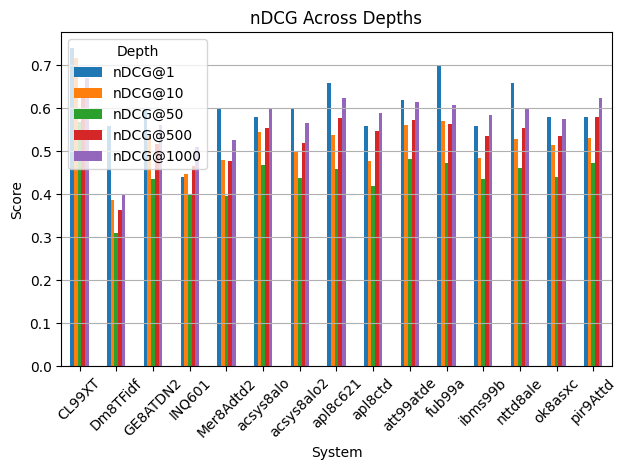

In [39]:
ndcg_comparison.plot(kind='bar')
plt.title('nDCG Across Depths')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Depth')
plt.show()


Spearman: nDCG @k


,nDCG@1,nDCG@10,nDCG@50,nDCG@500,nDCG@1000
nDCG@1,1.000000,0.789576,0.673940,0.616122,0.592633
nDCG@10,0.789576,1.000000,0.903571,0.785714,0.800000
nDCG@50,0.673940,0.903571,1.000000,0.892857,0.896429
nDCG@500,0.616122,0.785714,0.892857,1.000000,0.996429
nDCG@1000,0.592633,0.800000,0.896429,0.996429,1.000000



Kendall Tau: nDCG @k


,nDCG@1,nDCG@10,nDCG@50,nDCG@500,nDCG@1000
nDCG@1,1.000000,0.650814,0.530664,0.450564,0.430539
nDCG@10,0.650814,1.000000,0.790476,0.600000,0.619048
nDCG@50,0.530664,0.790476,1.000000,0.733333,0.752381
nDCG@500,0.450564,0.600000,0.733333,1.000000,0.980952
nDCG@1000,0.430539,0.619048,0.752381,0.980952,1.000000


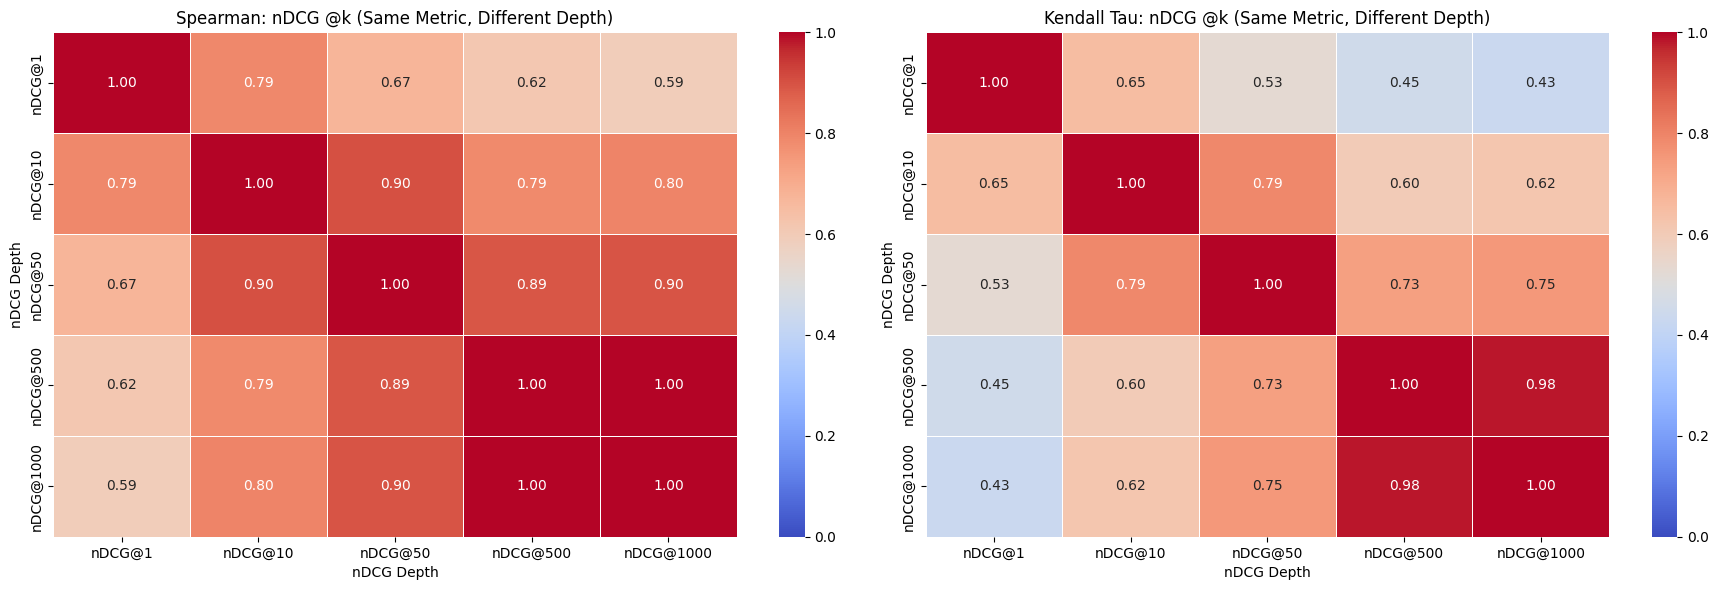

In [40]:
ndcg_depth_corr_spearman = ndcg_comparison.corr(method='spearman')
ndcg_depth_corr_kendall  = ndcg_comparison.corr(method='kendall')
print("\nSpearman: nDCG @k")
display(ndcg_depth_corr_spearman)
print("\nKendall Tau: nDCG @k")
display(ndcg_depth_corr_kendall)
plot_dual_heatmap(
    ndcg_depth_corr_spearman, ndcg_depth_corr_kendall,
    title_prefix="nDCG @k (Same Metric, Different Depth)",
    xlabel="nDCG Depth", ylabel="nDCG Depth"
)

### 3.2 Compare Different Metric at Same Depth

In [41]:
depths = [1, 10, 50, 500, 1000]
same_depth_results = []
 
for d in depths:
    metric_list = [f'P@{d}', f'MAP@{d}', f'nDCG@{d}']
    for i in range(len(metric_list)):
        for j in range(i + 1, len(metric_list)):
            metric_a = metric_list[i]
            metric_b = metric_list[j]
            scores_a = get_metric_scores(metric_a)
            scores_b = get_metric_scores(metric_b)
            spear_corr, spear_p = spearmanr(scores_a, scores_b)
            kend_corr,  kend_p  = kendalltau(scores_a, scores_b)
            same_depth_results.append({
                'Depth':            f'@{d}',
                'Metric Pair':      f'{metric_a} vs {metric_b}',
                'Spearman':         round(spear_corr, 6),
                'Spearman p-value': round(spear_p,    6),
                'Kendall Tau':      round(kend_corr,  6),
                'Kendall p-value':  round(kend_p,     6),
            })
 
same_depth_df = pd.DataFrame(same_depth_results)
print("=== Full Table: Same Depth, Different Metric ===")
display(same_depth_df)



=== Full Table: Same Depth, Different Metric ===


,Depth,Metric Pair,Spearman,Spearman p-value,Kendall Tau,Kendall p-value
0,@1,P@1 vs MAP@1,0.645031,0.009417,0.490614,0.013843
1,@1,P@1 vs nDCG@1,1.000000,0.000000,1.000000,0.000001
2,@1,MAP@1 vs nDCG@1,0.645031,0.009417,0.490614,0.013843
3,@10,P@10 vs MAP@10,0.823950,0.000159,0.689003,0.000360
4,@10,P@10 vs nDCG@10,0.979446,0.000000,0.918671,0.000002
5,@10,MAP@10 vs nDCG@10,0.864286,0.000032,0.733333,0.000037
6,@50,P@50 vs MAP@50,0.889286,0.000009,0.752381,0.000020
7,@50,P@50 vs nDCG@50,0.957143,0.000000,0.866667,0.000000
8,@50,MAP@50 vs nDCG@50,0.935714,0.000000,0.809524,0.000002
9,@500,P@500 vs MAP@500,0.957143,0.000000,0.866667,0.000000


#### 3.2.1 Depth (k)=1

             P@1     MAP@1  nDCG@1
CL99XT      0.74  0.018643    0.74
Dm8TFidf    0.56  0.013362    0.56
GE8ATDN2    0.60  0.016207    0.60
INQ601      0.44  0.011858    0.44
Mer8Adtd2   0.60  0.014656    0.60
acsys8alo   0.58  0.014283    0.58
acsys8alo2  0.60  0.016356    0.60
apl8c621    0.66  0.017370    0.66
apl8ctd     0.56  0.016495    0.56
att99atde   0.62  0.014879    0.62
fub99a      0.70  0.018844    0.70
ibms99b     0.56  0.016415    0.56
nttd8ale    0.66  0.019208    0.66
ok8asxc     0.58  0.016912    0.58
pir9Attd    0.58  0.017008    0.58


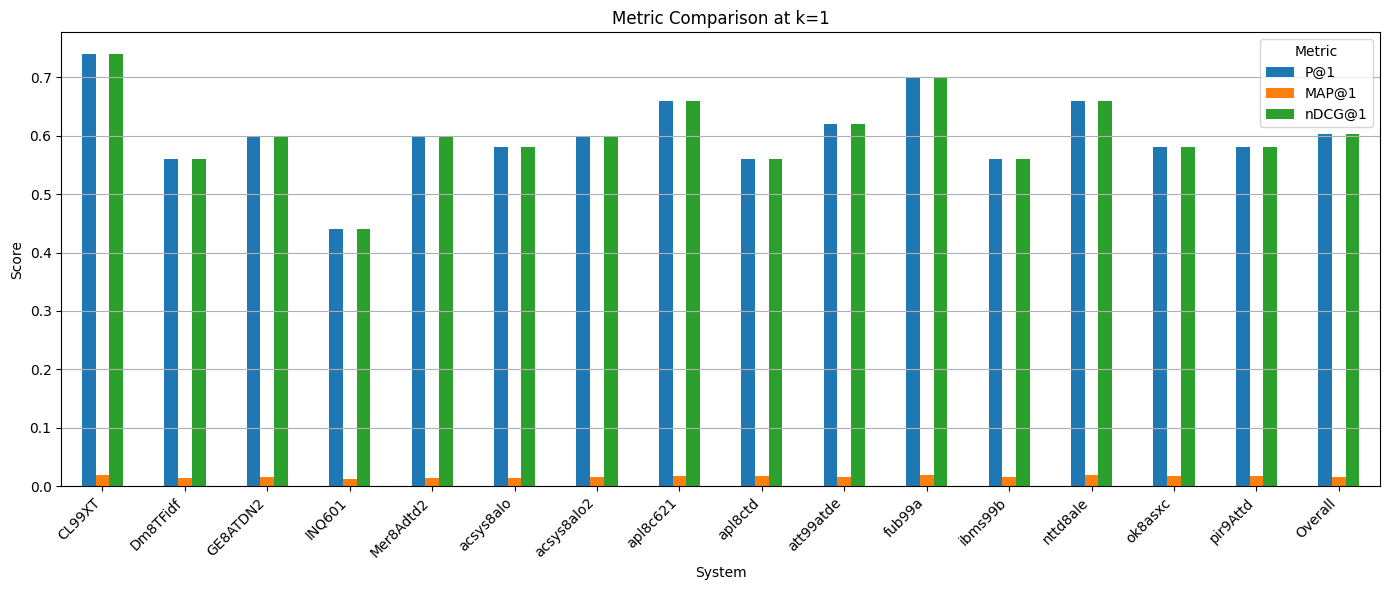

In [69]:
metric_comparison_1 = pd.DataFrame({
    'P@1':    get_metric_scores('P@1'),
    'MAP@1':  get_metric_scores('MAP@1'),
    'nDCG@1': get_metric_scores('nDCG@1'),
})
metric_comparison_1 = metric_comparison_1.drop(index='Overall', errors='ignore')
print(metric_comparison_1)
overall_row_1 = pd.Series({
    'P@1':    get_metric_scores('P@1').mean(),
    'MAP@1':  get_metric_scores('MAP@1').mean(),
    'nDCG@1': get_metric_scores('nDCG@1').mean(),
}, name='Overall')
metric_comparison_1 = pd.concat([metric_comparison_1, overall_row_1.to_frame().T])
metric_comparison_1.plot(kind='bar', figsize=(14, 6))
plt.title('Metric Comparison at k=1')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Metric')
plt.show()

In [43]:
print("\n--- Depth @1: P@1 vs MAP@1 vs nDCG@1 ---")
group_df_1    = same_depth_df[same_depth_df['Depth'] == '@1'].reset_index(drop=True)
metric_list_1 = ['P@1', 'MAP@1', 'nDCG@1']
display(group_df_1)


--- Depth @1: P@1 vs MAP@1 vs nDCG@1 ---


,Depth,Metric Pair,Spearman,Spearman p-value,Kendall Tau,Kendall p-value
0,@1,P@1 vs MAP@1,0.645031,0.009417,0.490614,0.013843
1,@1,P@1 vs nDCG@1,1.000000,0.000000,1.000000,0.000001
2,@1,MAP@1 vs nDCG@1,0.645031,0.009417,0.490614,0.013843


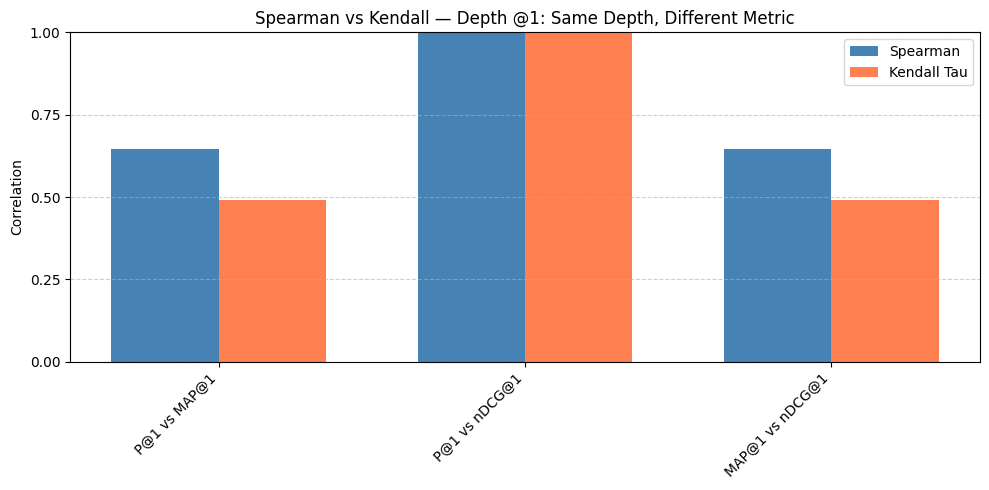

In [44]:
plot_correlation_bar_dual(
    group_df_1,
    "Spearman vs Kendall — Depth @1: Same Depth, Different Metric"
)


Spearman Matrix: Cross-Metric at Depth @1


,P@1,MAP@1,nDCG@1
P@1,1.00,0.65,1.00
MAP@1,0.65,1.00,0.65
nDCG@1,1.00,0.65,1.00



Kendall Tau Matrix: Cross-Metric at Depth @1


,P@1,MAP@1,nDCG@1
P@1,1.00,0.49,1.00
MAP@1,0.49,1.00,0.49
nDCG@1,1.00,0.49,1.00


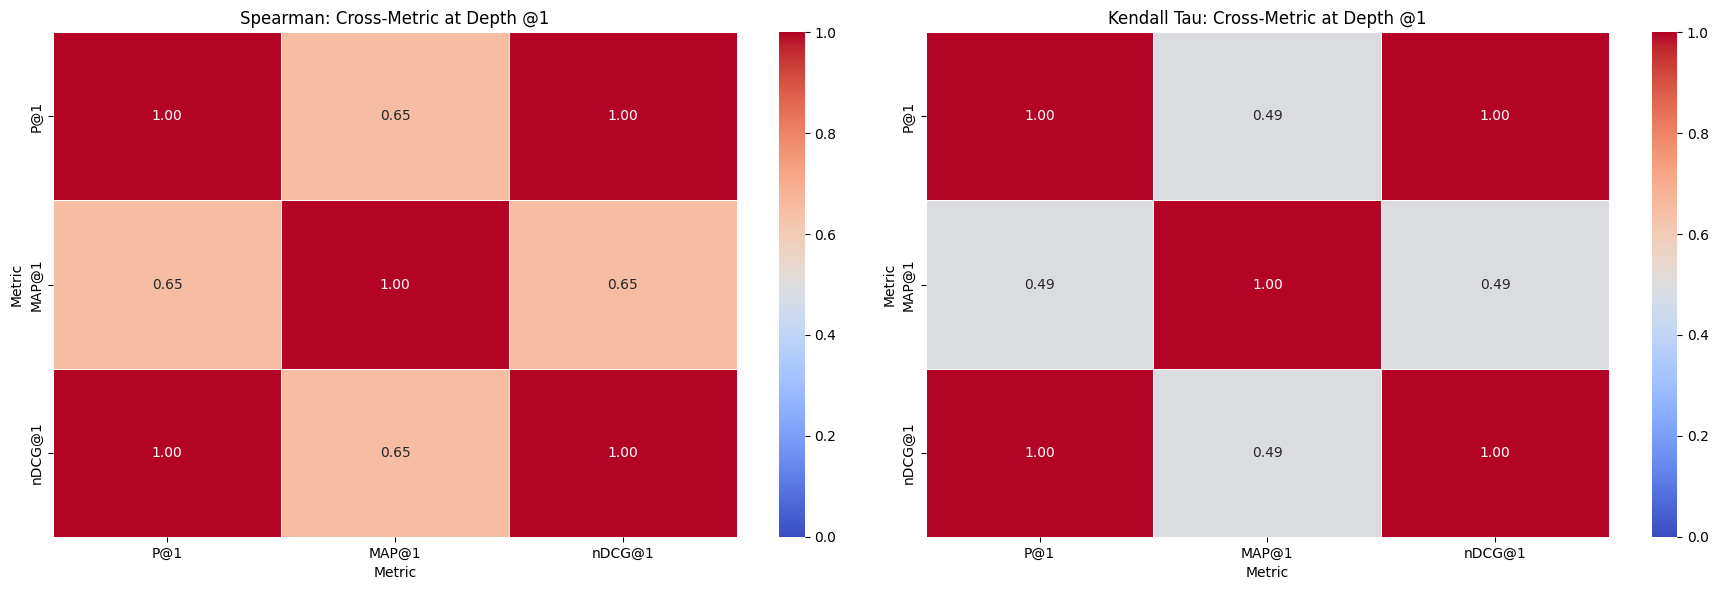

In [45]:
spear_mat_1 = cross_metric_corr_matrix(metric_list_1, metric_list_1, method='spearman')
kend_mat_1  = cross_metric_corr_matrix(metric_list_1, metric_list_1, method='kendall')
print("\nSpearman Matrix: Cross-Metric at Depth @1")
display(spear_mat_1)
print("\nKendall Tau Matrix: Cross-Metric at Depth @1")
display(kend_mat_1)
plot_dual_heatmap(
    spear_mat_1, kend_mat_1,
    title_prefix="Cross-Metric at Depth @1",
    xlabel="Metric", ylabel="Metric"
)

#### 3.2.2 Depth (k)=10

             P@10    MAP@10   nDCG@10
CL99XT      0.692  0.130851  0.716428
Dm8TFidf    0.344  0.073952  0.385672
GE8ATDN2    0.512  0.088222  0.536085
INQ601      0.436  0.080583  0.447578
Mer8Adtd2   0.444  0.077695  0.480382
acsys8alo   0.530  0.101239  0.543947
acsys8alo2  0.474  0.095007  0.499038
apl8c621    0.504  0.105636  0.539067
apl8ctd     0.450  0.091294  0.476374
att99atde   0.548  0.099052  0.562190
fub99a      0.530  0.109134  0.571617
ibms99b     0.460  0.086451  0.485459
nttd8ale    0.494  0.101036  0.527770
ok8asxc     0.488  0.096093  0.515674
pir9Attd    0.508  0.102863  0.531018


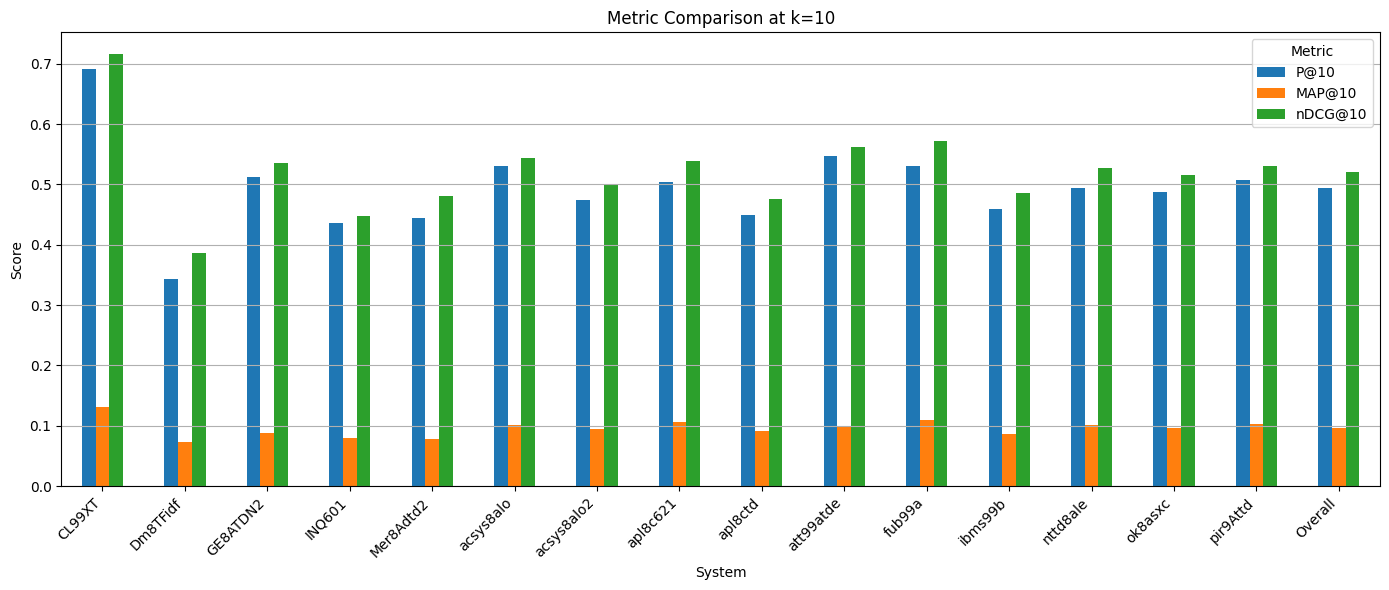

In [71]:
metric_comparison_10 = pd.DataFrame({
    'P@10':    get_metric_scores('P@10'),
    'MAP@10':  get_metric_scores('MAP@10'),
    'nDCG@10': get_metric_scores('nDCG@10'),
})
metric_comparison_10 = metric_comparison_10.drop(index='Overall', errors='ignore')
print(metric_comparison_10)
overall_row_10 = pd.Series({
    'P@10':    get_metric_scores('P@10').mean(),
    'MAP@10':  get_metric_scores('MAP@10').mean(),
    'nDCG@10': get_metric_scores('nDCG@10').mean(),
}, name='Overall')
metric_comparison_10 = pd.concat([metric_comparison_10, overall_row_10.to_frame().T])
metric_comparison_10.plot(kind='bar', figsize=(14, 6))
plt.title('Metric Comparison at k=10')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Metric')
plt.show()

In [47]:
print("\n--- Depth @10: P@10 vs MAP@10 vs nDCG@10 ---")
group_df_10    = same_depth_df[same_depth_df['Depth'] == '@10'].reset_index(drop=True)
metric_list_10 = ['P@10', 'MAP@10', 'nDCG@10']
display(group_df_10)


--- Depth @10: P@10 vs MAP@10 vs nDCG@10 ---


,Depth,Metric Pair,Spearman,Spearman p-value,Kendall Tau,Kendall p-value
0,@10,P@10 vs MAP@10,0.823950,0.000159,0.689003,0.000360
1,@10,P@10 vs nDCG@10,0.979446,0.000000,0.918671,0.000002
2,@10,MAP@10 vs nDCG@10,0.864286,0.000032,0.733333,0.000037


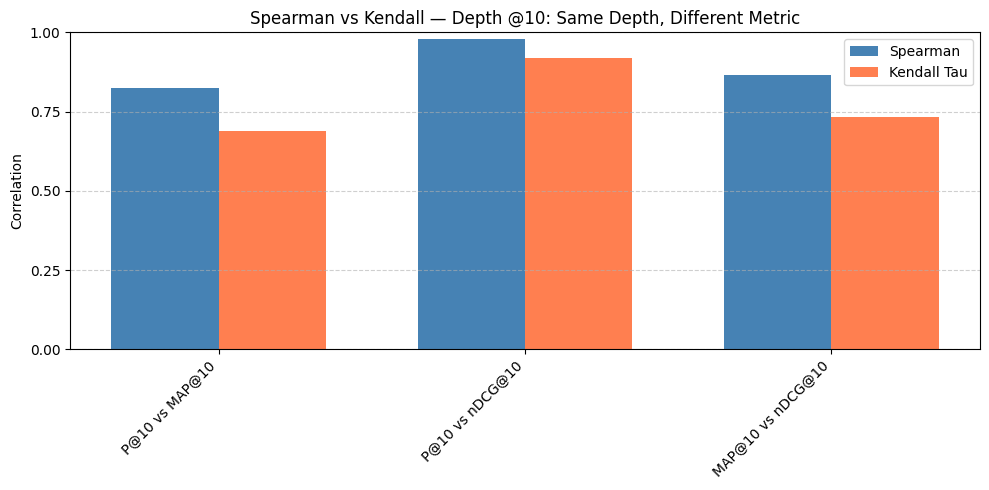

In [48]:
plot_correlation_bar_dual(
    group_df_10,
    "Spearman vs Kendall — Depth @10: Same Depth, Different Metric"
)


Spearman Matrix: Cross-Metric at Depth @10


,P@10,MAP@10,nDCG@10
P@10,1.00,0.82,0.98
MAP@10,0.82,1.00,0.86
nDCG@10,0.98,0.86,1.00



Kendall Tau Matrix: Cross-Metric at Depth @10


,P@10,MAP@10,nDCG@10
P@10,1.00,0.69,0.92
MAP@10,0.69,1.00,0.73
nDCG@10,0.92,0.73,1.00


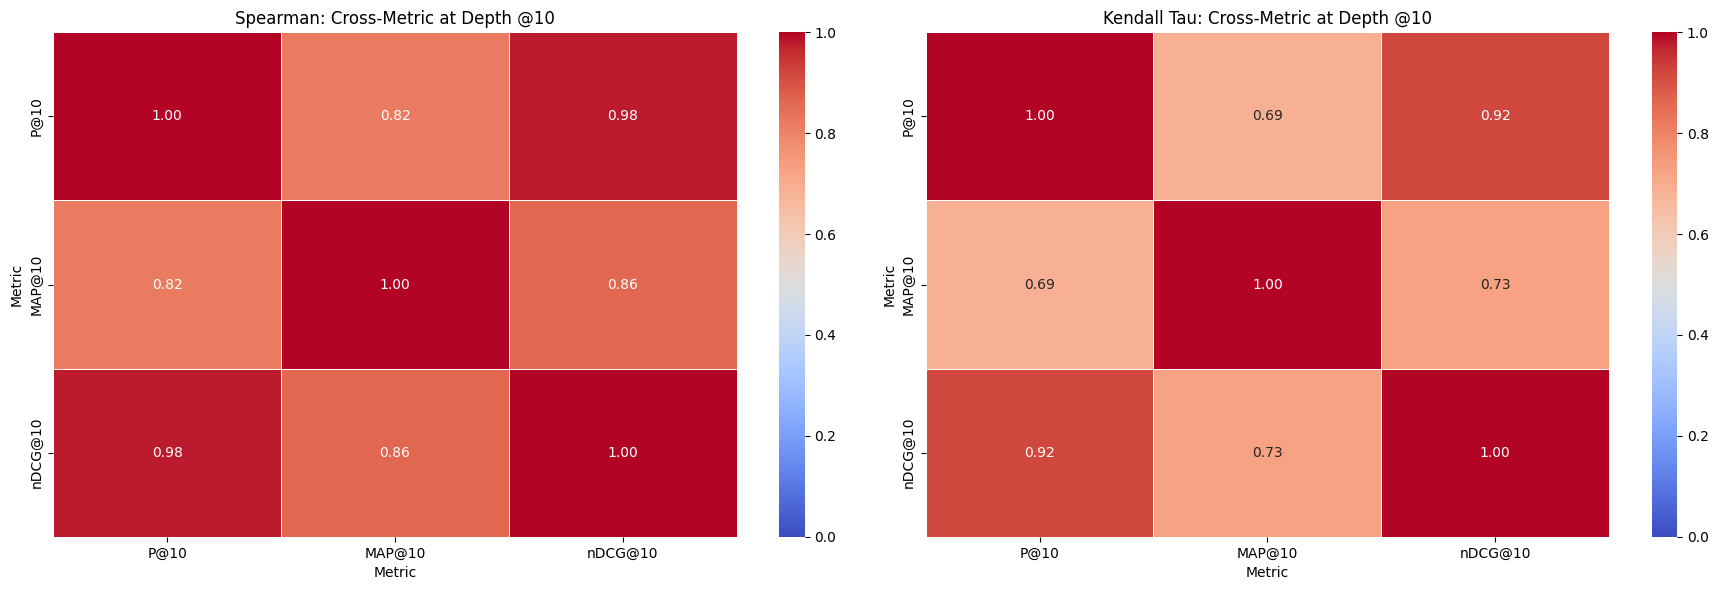

In [49]:
spear_mat_10 = cross_metric_corr_matrix(metric_list_10, metric_list_10, method='spearman')
kend_mat_10  = cross_metric_corr_matrix(metric_list_10, metric_list_10, method='kendall')
print("\nSpearman Matrix: Cross-Metric at Depth @10")
display(spear_mat_10)
print("\nKendall Tau Matrix: Cross-Metric at Depth @10")
display(kend_mat_10)
plot_dual_heatmap(
    spear_mat_10, kend_mat_10,
    title_prefix="Cross-Metric at Depth @10",
    xlabel="Metric", ylabel="Metric"
)

#### 3.2.3 Depth (k)=50

              P@50    MAP@50   nDCG@50
CL99XT      0.4032  0.254829  0.569267
Dm8TFidf    0.1992  0.123216  0.310467
GE8ATDN2    0.3200  0.162401  0.434540
INQ601      0.2896  0.157460  0.397585
Mer8Adtd2   0.2788  0.146641  0.395043
acsys8alo   0.3452  0.191688  0.468979
acsys8alo2  0.3168  0.174114  0.438665
apl8c621    0.3196  0.200697  0.458823
apl8ctd     0.2984  0.182511  0.419386
att99atde   0.3572  0.201852  0.483185
fub99a      0.3396  0.198416  0.473795
ibms99b     0.3192  0.176557  0.436206
nttd8ale    0.3276  0.193072  0.461871
ok8asxc     0.3220  0.182632  0.440978
pir9Attd    0.3456  0.206589  0.473474


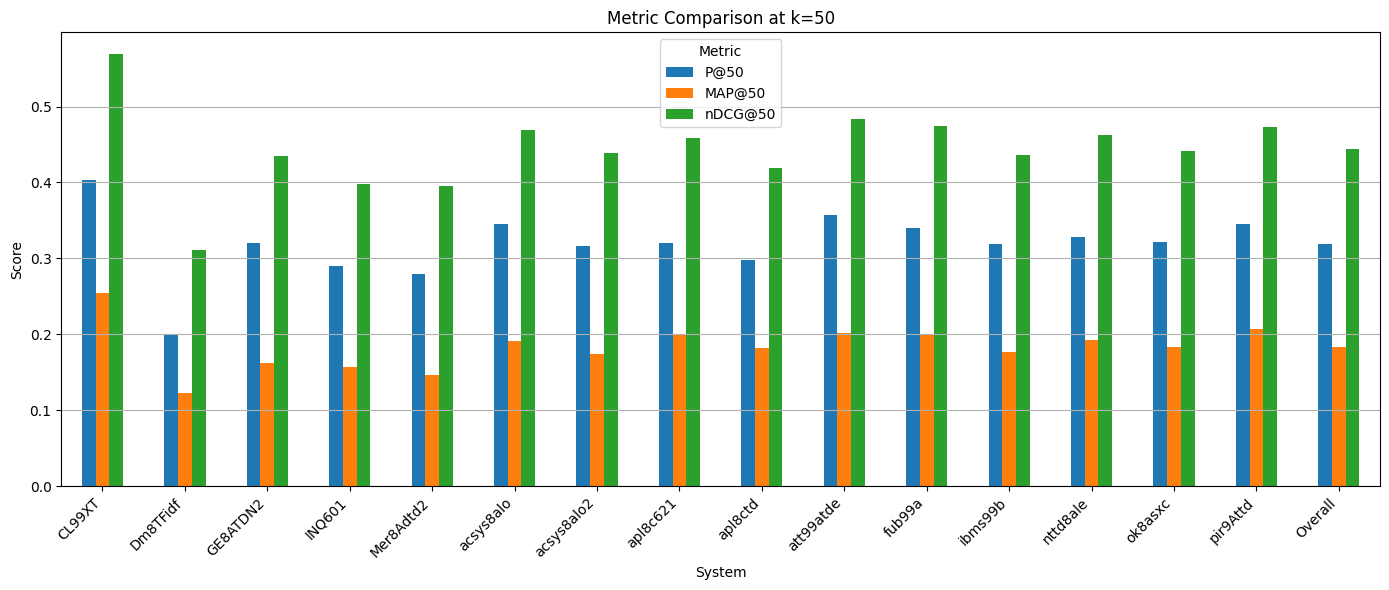

In [72]:
metric_comparison_50 = pd.DataFrame({
    'P@50':    get_metric_scores('P@50'),
    'MAP@50':  get_metric_scores('MAP@50'),
    'nDCG@50': get_metric_scores('nDCG@50'),
})
metric_comparison_50 = metric_comparison_50.drop(index='Overall', errors='ignore')
print(metric_comparison_50)
overall_row_50 = pd.Series({
    'P@50':    get_metric_scores('P@50').mean(),
    'MAP@50':  get_metric_scores('MAP@50').mean(),
    'nDCG@50': get_metric_scores('nDCG@50').mean(),
}, name='Overall')
metric_comparison_50 = pd.concat([metric_comparison_50, overall_row_50.to_frame().T])
metric_comparison_50.plot(kind='bar', figsize=(14, 6))
plt.title('Metric Comparison at k=50')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Metric')
plt.show()

In [51]:
print("\n--- Depth @50: P@50 vs MAP@50 vs nDCG@50 ---")
group_df_50    = same_depth_df[same_depth_df['Depth'] == '@50'].reset_index(drop=True)
metric_list_50 = ['P@50', 'MAP@50', 'nDCG@50']
display(group_df_50)


--- Depth @50: P@50 vs MAP@50 vs nDCG@50 ---


,Depth,Metric Pair,Spearman,Spearman p-value,Kendall Tau,Kendall p-value
0,@50,P@50 vs MAP@50,0.889286,0.000009,0.752381,0.000020
1,@50,P@50 vs nDCG@50,0.957143,0.000000,0.866667,0.000000
2,@50,MAP@50 vs nDCG@50,0.935714,0.000000,0.809524,0.000002


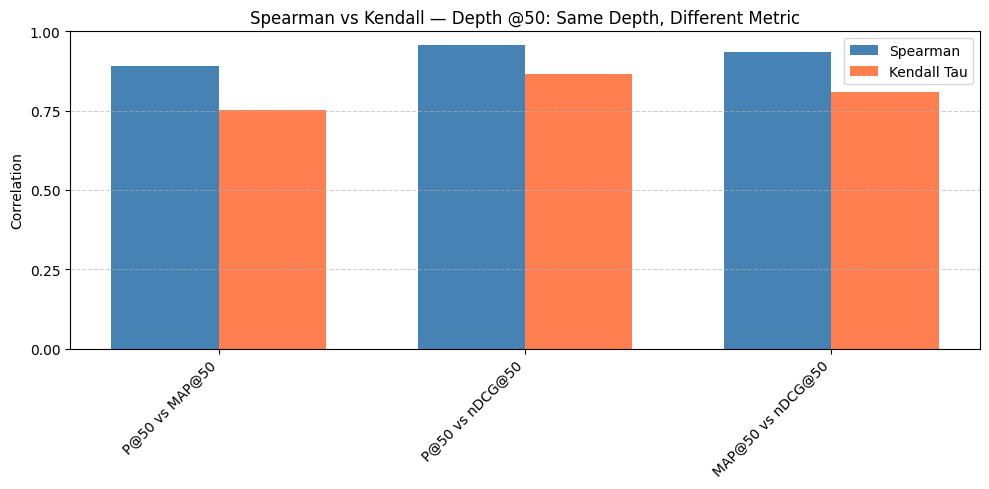

In [52]:
plot_correlation_bar_dual(
    group_df_50,
    "Spearman vs Kendall — Depth @50: Same Depth, Different Metric"
)


Spearman Matrix: Cross-Metric at Depth @50


,P@50,MAP@50,nDCG@50
P@50,1.00,0.89,0.96
MAP@50,0.89,1.00,0.94
nDCG@50,0.96,0.94,1.00



Kendall Tau Matrix: Cross-Metric at Depth @50


,P@50,MAP@50,nDCG@50
P@50,1.00,0.75,0.87
MAP@50,0.75,1.00,0.81
nDCG@50,0.87,0.81,1.00


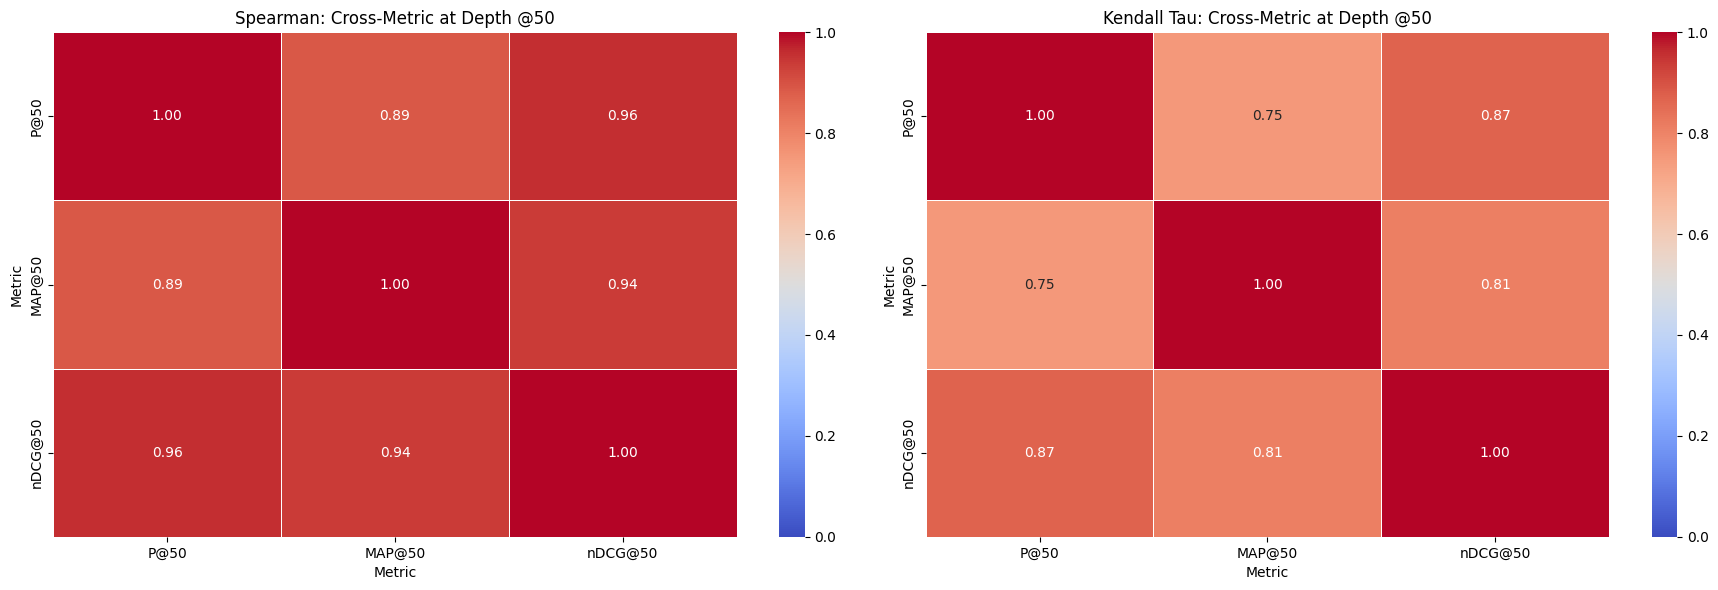

In [53]:
spear_mat_50 = cross_metric_corr_matrix(metric_list_50, metric_list_50, method='spearman')
kend_mat_50  = cross_metric_corr_matrix(metric_list_50, metric_list_50, method='kendall')
print("\nSpearman Matrix: Cross-Metric at Depth @50")
display(spear_mat_50)
print("\nKendall Tau Matrix: Cross-Metric at Depth @50")
display(kend_mat_50)
plot_dual_heatmap(
    spear_mat_50, kend_mat_50,
    title_prefix="Cross-Metric at Depth @50",
    xlabel="Metric", ylabel="Metric"
)

#### 3.2.4 Depth (k)=500

              P@500   MAP@500  nDCG@500
CL99XT      0.11728  0.365231  0.635339
Dm8TFidf    0.06044  0.158051  0.363569
GE8ATDN2    0.10172  0.249442  0.517872
INQ601      0.08716  0.224815  0.466935
Mer8Adtd2   0.09000  0.214131  0.477580
acsys8alo   0.11024  0.283580  0.554467
acsys8alo2  0.10096  0.254326  0.519811
apl8c621    0.10988  0.302168  0.577955
apl8ctd     0.10260  0.277154  0.546654
att99atde   0.11004  0.307403  0.573058
fub99a      0.10880  0.296584  0.563089
ibms99b     0.10252  0.268259  0.536144
nttd8ale    0.10376  0.282753  0.554515
ok8asxc     0.10120  0.270699  0.535453
pir9Attd    0.11168  0.310372  0.579152


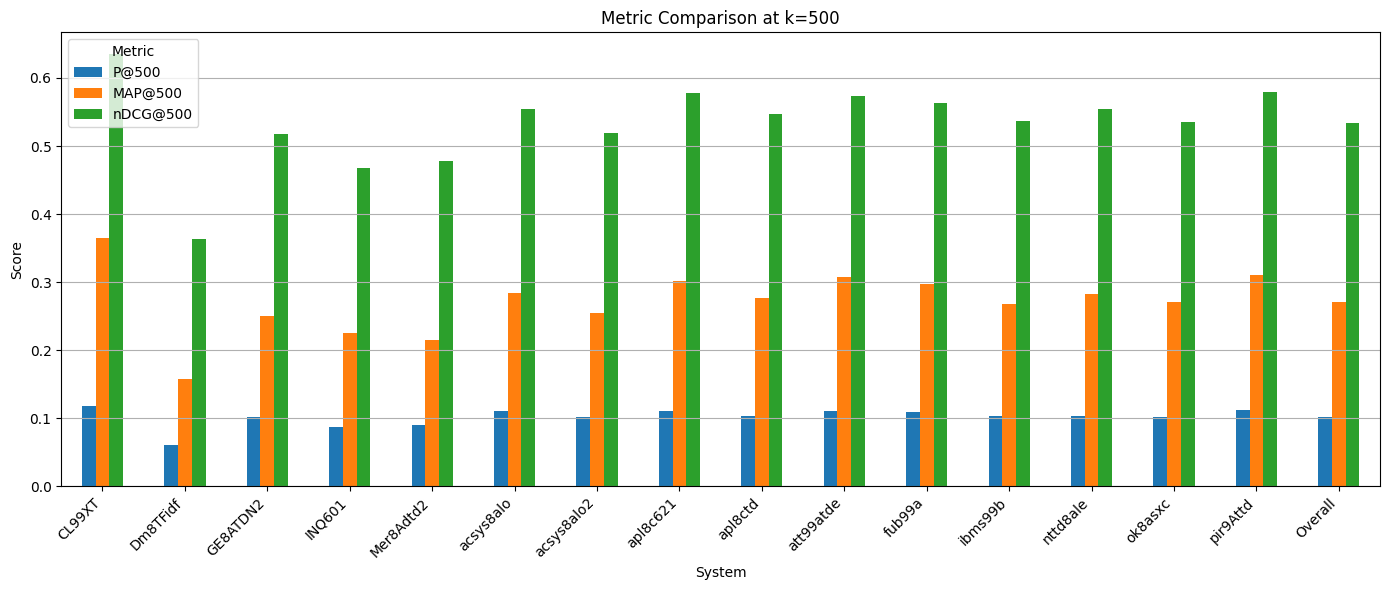

In [ ]:
metric_comparison_500 = pd.DataFrame({
    'P@500':    get_metric_scores('P@500'),
    'MAP@500':  get_metric_scores('MAP@500'),
    'nDCG@500': get_metric_scores('nDCG@500'),
})
metric_comparison_500 = metric_comparison_500.drop(index='Overall', errors='ignore')
print(metric_comparison_500)
overall_row_500 = pd.Series({
    'P@500':    get_metric_scores('P@500').mean(),
    'MAP@500':  get_metric_scores('MAP@500').mean(),
    'nDCG@500': get_metric_scores('nDCG@500').mean(),
}, name='Overall')
metric_comparison_500 = pd.concat([metric_comparison_500, overall_row_500.to_frame().T])
metric_comparison_500.plot(kind='bar', figsize=(14, 6))
plt.title('Metric Comparison at k=500')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Metric')
plt.show()

In [55]:
print("\n--- Depth @500: P@500 vs MAP@500 vs nDCG@500 ---")
group_df_500    = same_depth_df[same_depth_df['Depth'] == '@500'].reset_index(drop=True)
metric_list_500 = ['P@500', 'MAP@500', 'nDCG@500']
display(group_df_500)


--- Depth @500: P@500 vs MAP@500 vs nDCG@500 ---


,Depth,Metric Pair,Spearman,Spearman p-value,Kendall Tau,Kendall p-value
0,@500,P@500 vs MAP@500,0.957143,0.0,0.866667,0.0
1,@500,P@500 vs nDCG@500,0.950000,0.0,0.866667,0.0
2,@500,MAP@500 vs nDCG@500,0.985714,0.0,0.923810,0.0


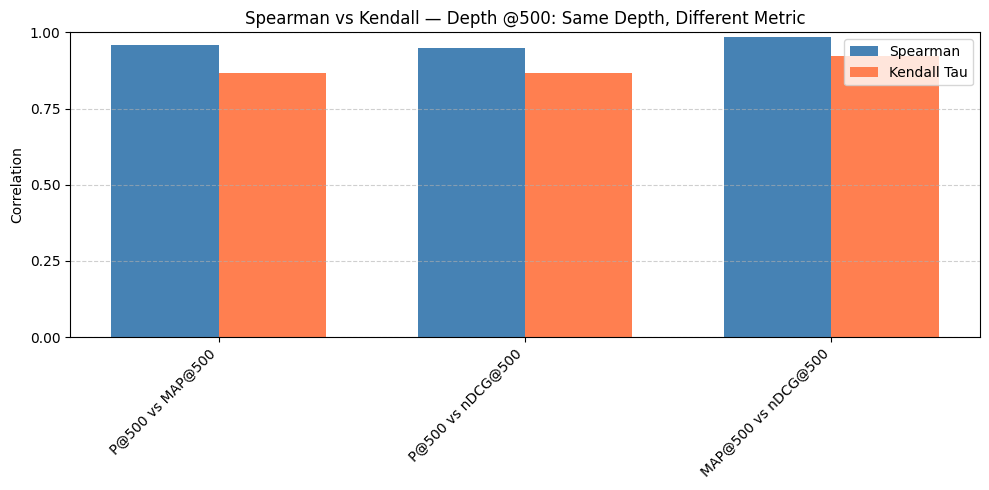

In [56]:
plot_correlation_bar_dual(
    group_df_500,
    "Spearman vs Kendall — Depth @500: Same Depth, Different Metric"
)


Spearman Matrix: Cross-Metric at Depth @500


,P@500,MAP@500,nDCG@500
P@500,1.00,0.96,0.95
MAP@500,0.96,1.00,0.99
nDCG@500,0.95,0.99,1.00



Kendall Tau Matrix: Cross-Metric at Depth @500


,P@500,MAP@500,nDCG@500
P@500,1.00,0.87,0.87
MAP@500,0.87,1.00,0.92
nDCG@500,0.87,0.92,1.00


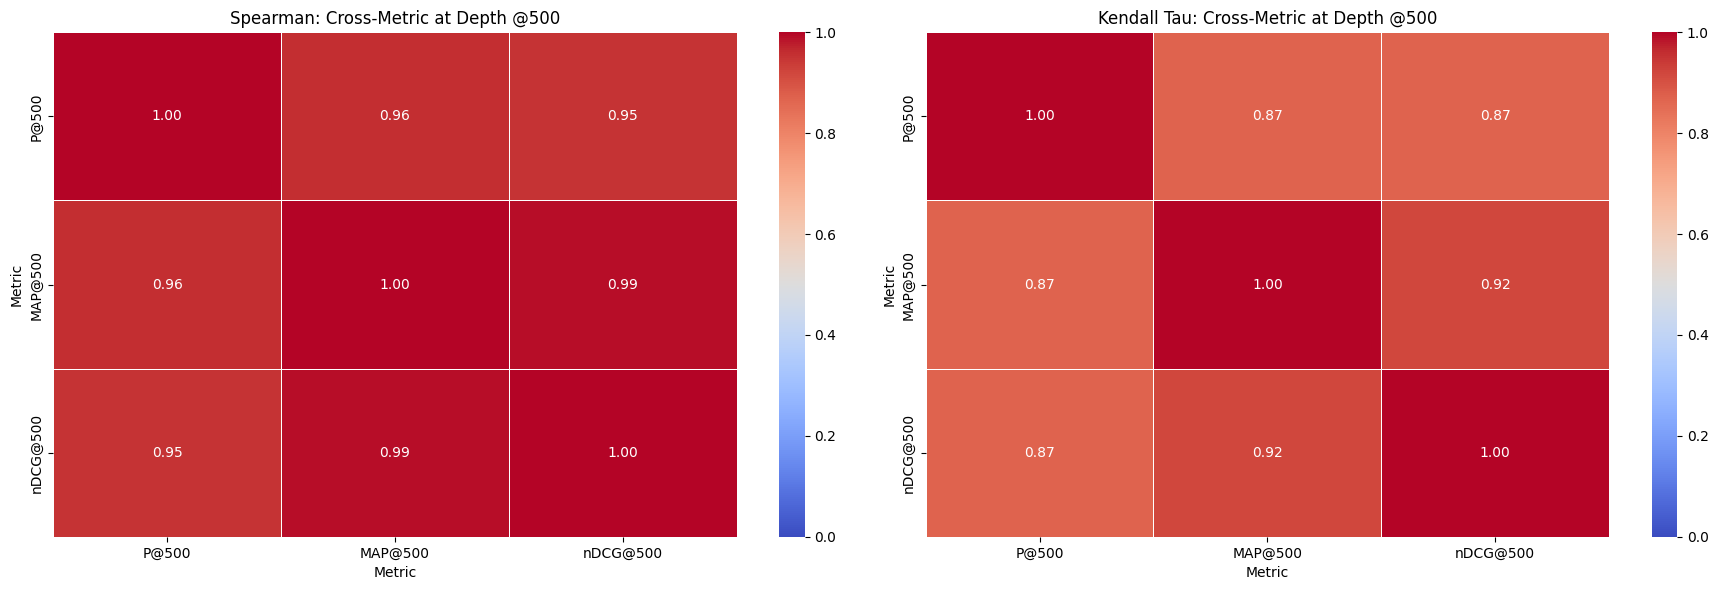

In [57]:
spear_mat_500 = cross_metric_corr_matrix(metric_list_500, metric_list_500, method='spearman')
kend_mat_500  = cross_metric_corr_matrix(metric_list_500, metric_list_500, method='kendall')
print("\nSpearman Matrix: Cross-Metric at Depth @500")
display(spear_mat_500)
print("\nKendall Tau Matrix: Cross-Metric at Depth @500")
display(kend_mat_500)
plot_dual_heatmap(
    spear_mat_500, kend_mat_500,
    title_prefix="Cross-Metric at Depth @500",
    xlabel="Metric", ylabel="Metric"
)

#### 3.2.5 Depth (k)=1000

             P@1000  MAP@1000  nDCG@1000
CL99XT      0.06734  0.373043   0.671461
Dm8TFidf    0.03844  0.163035   0.399003
GE8ATDN2    0.06136  0.257968   0.561775
INQ601      0.05402  0.232549   0.509582
Mer8Adtd2   0.05662  0.223131   0.526250
acsys8alo   0.06624  0.293502   0.601051
acsys8alo2  0.06160  0.263668   0.566490
apl8c621    0.06670  0.312633   0.624432
apl8ctd     0.06234  0.285989   0.590040
att99atde   0.06512  0.316549   0.615255
fub99a      0.06524  0.306768   0.608483
ibms99b     0.06302  0.278388   0.585271
nttd8ale    0.06240  0.292138   0.598381
ok8asxc     0.06026  0.278696   0.576401
pir9Attd    0.06684  0.320659   0.625149


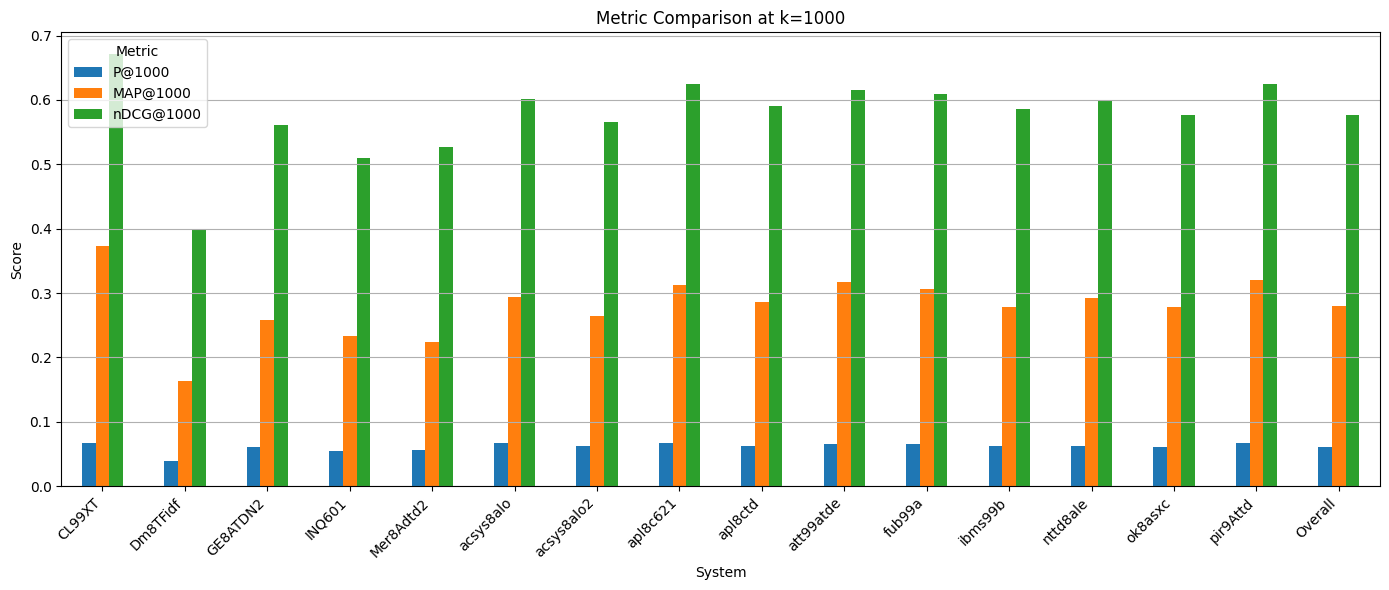

In [73]:
metric_comparison_1000 = pd.DataFrame({
    'P@1000':    get_metric_scores('P@1000'),
    'MAP@1000':  get_metric_scores('MAP@1000'),
    'nDCG@1000': get_metric_scores('nDCG@1000'),
})
metric_comparison_1000 = metric_comparison_1000.drop(index='Overall', errors='ignore')
print(metric_comparison_1000)
overall_row_1000 = pd.Series({
    'P@1000':    get_metric_scores('P@1000').mean(),
    'MAP@1000':  get_metric_scores('MAP@1000').mean(),
    'nDCG@1000': get_metric_scores('nDCG@1000').mean(),
}, name='Overall')
metric_comparison_1000 = pd.concat([metric_comparison_1000, overall_row_1000.to_frame().T])
metric_comparison_1000.plot(kind='bar', figsize=(14, 6))
plt.title('Metric Comparison at k=1000')
plt.ylabel('Score')
plt.xlabel('System')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.legend(title='Metric')
plt.show()

In [59]:
print("\n--- Depth @1000: P@1000 vs MAP@1000 vs nDCG@1000 ---")
group_df_1000    = same_depth_df[same_depth_df['Depth'] == '@1000'].reset_index(drop=True)
metric_list_1000 = ['P@1000', 'MAP@1000', 'nDCG@1000']
display(group_df_1000)


--- Depth @1000: P@1000 vs MAP@1000 vs nDCG@1000 ---


,Depth,Metric Pair,Spearman,Spearman p-value,Kendall Tau,Kendall p-value
0,@1000,P@1000 vs MAP@1000,0.932143,0.0,0.809524,0.000002
1,@1000,P@1000 vs nDCG@1000,0.964286,0.0,0.866667,0.000000
2,@1000,MAP@1000 vs nDCG@1000,0.989286,0.0,0.942857,0.000000


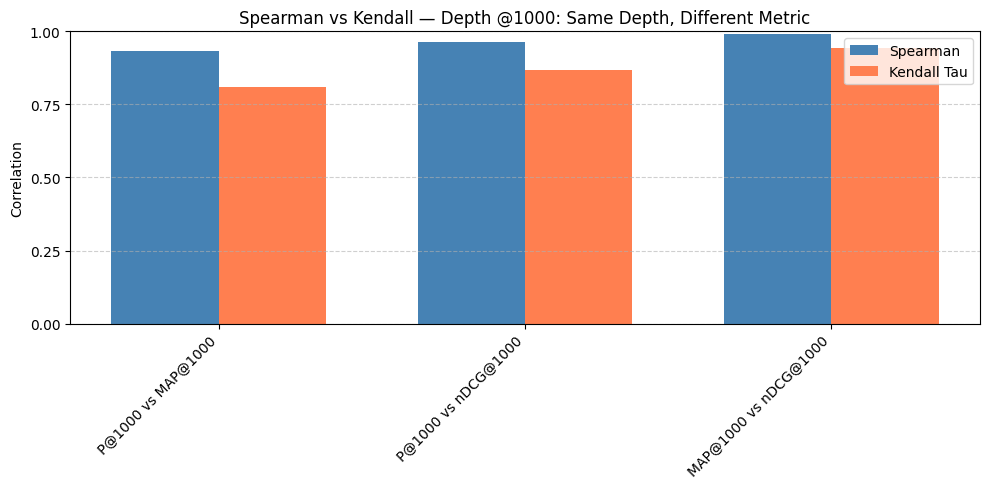

In [60]:
plot_correlation_bar_dual(
    group_df_1000,
    "Spearman vs Kendall — Depth @1000: Same Depth, Different Metric"
)


Spearman Matrix: Cross-Metric at Depth @1000


,P@1000,MAP@1000,nDCG@1000
P@1000,1.00,0.93,0.96
MAP@1000,0.93,1.00,0.99
nDCG@1000,0.96,0.99,1.00



Kendall Tau Matrix: Cross-Metric at Depth @1000


,P@1000,MAP@1000,nDCG@1000
P@1000,1.00,0.81,0.87
MAP@1000,0.81,1.00,0.94
nDCG@1000,0.87,0.94,1.00


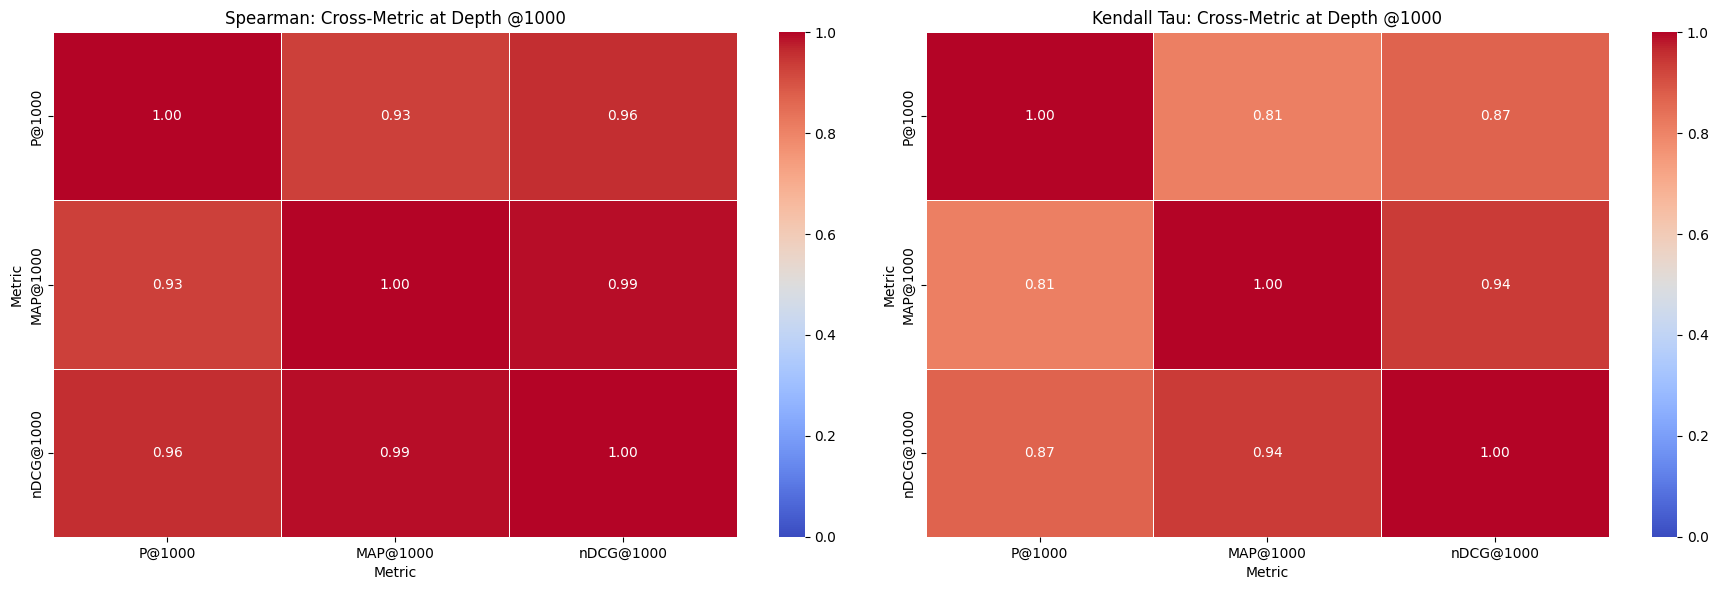

In [61]:
spear_mat_1000 = cross_metric_corr_matrix(metric_list_1000, metric_list_1000, method='spearman')
kend_mat_1000  = cross_metric_corr_matrix(metric_list_1000, metric_list_1000, method='kendall')
print("\nSpearman Matrix: Cross-Metric at Depth @1000")
display(spear_mat_1000)
print("\nKendall Tau Matrix: Cross-Metric at Depth @1000")
display(kend_mat_1000)
plot_dual_heatmap(
    spear_mat_1000, kend_mat_1000,
    title_prefix="Cross-Metric at Depth @1000",
    xlabel="Metric", ylabel="Metric"
)

### 3.3: All Metrics 15x15 Matrix

In [62]:
print("\n" + "=" * 60)
print("SECTION 3.3: Full Correlation Matrix — All 15 Metrics")
print("=" * 60)
 
all_metric_comparison = pd.DataFrame({
    metric: get_metric_scores(metric)
    for metric in all_metric_cols
})
all_metric_comparison.index.name = 'System'
all_metric_comparison = all_metric_comparison.drop(index='Overall', errors='ignore')
 
print("=== All Metrics Comparison Table ===")
display(all_metric_comparison)
 


SECTION 3.3: Full Correlation Matrix — All 15 Metrics
=== All Metrics Comparison Table ===


,P@1,P@10,P@50,P@500,P@1000,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000,nDCG@1,nDCG@10,nDCG@50,nDCG@500,nDCG@1000
System,,,,,,,,,,,,,,,
CL99XT,0.74,0.692,0.4032,0.11728,0.06734,0.018643,0.130851,0.254829,0.365231,0.373043,0.74,0.716428,0.569267,0.635339,0.671461
Dm8TFidf,0.56,0.344,0.1992,0.06044,0.03844,0.013362,0.073952,0.123216,0.158051,0.163035,0.56,0.385672,0.310467,0.363569,0.399003
GE8ATDN2,0.60,0.512,0.3200,0.10172,0.06136,0.016207,0.088222,0.162401,0.249442,0.257968,0.60,0.536085,0.434540,0.517872,0.561775
INQ601,0.44,0.436,0.2896,0.08716,0.05402,0.011858,0.080583,0.157460,0.224815,0.232549,0.44,0.447578,0.397585,0.466935,0.509582
Mer8Adtd2,0.60,0.444,0.2788,0.09000,0.05662,0.014656,0.077695,0.146641,0.214131,0.223131,0.60,0.480382,0.395043,0.477580,0.526250
acsys8alo,0.58,0.530,0.3452,0.11024,0.06624,0.014283,0.101239,0.191688,0.283580,0.293502,0.58,0.543947,0.468979,0.554467,0.601051
acsys8alo2,0.60,0.474,0.3168,0.10096,0.06160,0.016356,0.095007,0.174114,0.254326,0.263668,0.60,0.499038,0.438665,0.519811,0.566490
apl8c621,0.66,0.504,0.3196,0.10988,0.06670,0.017370,0.105636,0.200697,0.302168,0.312633,0.66,0.539067,0.458823,0.577955,0.624432
apl8ctd,0.56,0.450,0.2984,0.10260,0.06234,0.016495,0.091294,0.182511,0.277154,0.285989,0.56,0.476374,0.419386,0.546654,0.590040


In [63]:
# Spearman matrix 
all_metric_corr_spearman = all_metric_comparison.corr(method='spearman')

In [64]:
# Kendall matrix
all_metric_corr_kendall  = all_metric_comparison.corr(method='kendall')

In [65]:
print("\nSpearman Correlation Matrix — All Metrics")
display(all_metric_corr_spearman)
print("\nKendall Tau Correlation Matrix — All Metrics")
display(all_metric_corr_kendall)
 


Spearman Correlation Matrix — All Metrics


,P@1,P@10,P@50,P@500,P@1000,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000,nDCG@1,nDCG@10,nDCG@50,nDCG@500,nDCG@1000
P@1,1.000000,0.707094,0.579986,0.527588,0.543850,0.645031,0.706462,0.603474,0.569145,0.569145,1.000000,0.789576,0.673940,0.616122,0.592633
P@10,0.707094,1.000000,0.934764,0.848973,0.784629,0.448615,0.823950,0.807864,0.813226,0.813226,0.707094,0.979446,0.907954,0.775693,0.791779
P@50,0.579986,0.934764,1.000000,0.885714,0.800000,0.507143,0.832143,0.889286,0.878571,0.878571,0.579986,0.889286,0.957143,0.832143,0.839286
P@500,0.527588,0.848973,0.885714,1.000000,0.960714,0.546429,0.871429,0.932143,0.957143,0.957143,0.527588,0.825000,0.885714,0.950000,0.964286
P@1000,0.543850,0.784629,0.800000,0.960714,1.000000,0.600000,0.885714,0.907143,0.932143,0.932143,0.543850,0.796429,0.853571,0.950000,0.964286
MAP@1,0.645031,0.448615,0.507143,0.546429,0.600000,1.000000,0.732143,0.685714,0.639286,0.639286,0.645031,0.507143,0.592857,0.710714,0.667857
MAP@10,0.706462,0.823950,0.832143,0.871429,0.885714,0.732143,1.000000,0.921429,0.917857,0.917857,0.706462,0.864286,0.910714,0.910714,0.914286
MAP@50,0.603474,0.807864,0.889286,0.932143,0.907143,0.685714,0.921429,1.000000,0.992857,0.992857,0.603474,0.807143,0.935714,0.982143,0.978571
MAP@500,0.569145,0.813226,0.878571,0.957143,0.932143,0.639286,0.917857,0.992857,1.000000,1.000000,0.569145,0.807143,0.925000,0.985714,0.989286
MAP@1000,0.569145,0.813226,0.878571,0.957143,0.932143,0.639286,0.917857,0.992857,1.000000,1.000000,0.569145,0.807143,0.925000,0.985714,0.989286



Kendall Tau Correlation Matrix — All Metrics


,P@1,P@10,P@50,P@500,P@1000,MAP@1,MAP@10,MAP@50,MAP@500,MAP@1000,nDCG@1,nDCG@10,nDCG@50,nDCG@500,nDCG@1000
P@1,1.000000,0.563391,0.450564,0.370463,0.430539,0.490614,0.590739,0.450564,0.410513,0.410513,1.000000,0.650814,0.530664,0.450564,0.430539
P@10,0.563391,1.000000,0.822976,0.708142,0.612447,0.325363,0.689003,0.669864,0.669864,0.669864,0.563391,0.918671,0.822976,0.631586,0.650725
P@50,0.450564,0.822976,1.000000,0.733333,0.638095,0.371429,0.695238,0.752381,0.752381,0.752381,0.450564,0.733333,0.866667,0.676190,0.695238
P@500,0.370463,0.708142,0.733333,1.000000,0.866667,0.409524,0.695238,0.828571,0.866667,0.866667,0.370463,0.657143,0.714286,0.866667,0.885714
P@1000,0.430539,0.612447,0.638095,0.866667,1.000000,0.428571,0.714286,0.771429,0.809524,0.809524,0.430539,0.600000,0.657143,0.847619,0.866667
MAP@1,0.490614,0.325363,0.371429,0.409524,0.428571,1.000000,0.561905,0.542857,0.504762,0.504762,0.490614,0.371429,0.466667,0.542857,0.523810
MAP@10,0.590739,0.689003,0.695238,0.695238,0.714286,0.561905,1.000000,0.790476,0.790476,0.790476,0.590739,0.733333,0.790476,0.752381,0.771429
MAP@50,0.450564,0.669864,0.752381,0.828571,0.771429,0.542857,0.790476,1.000000,0.961905,0.961905,0.450564,0.638095,0.809524,0.923810,0.904762
MAP@500,0.410513,0.669864,0.752381,0.866667,0.809524,0.504762,0.790476,0.961905,1.000000,1.000000,0.410513,0.638095,0.809524,0.923810,0.942857
MAP@1000,0.410513,0.669864,0.752381,0.866667,0.809524,0.504762,0.790476,0.961905,1.000000,1.000000,0.410513,0.638095,0.809524,0.923810,0.942857


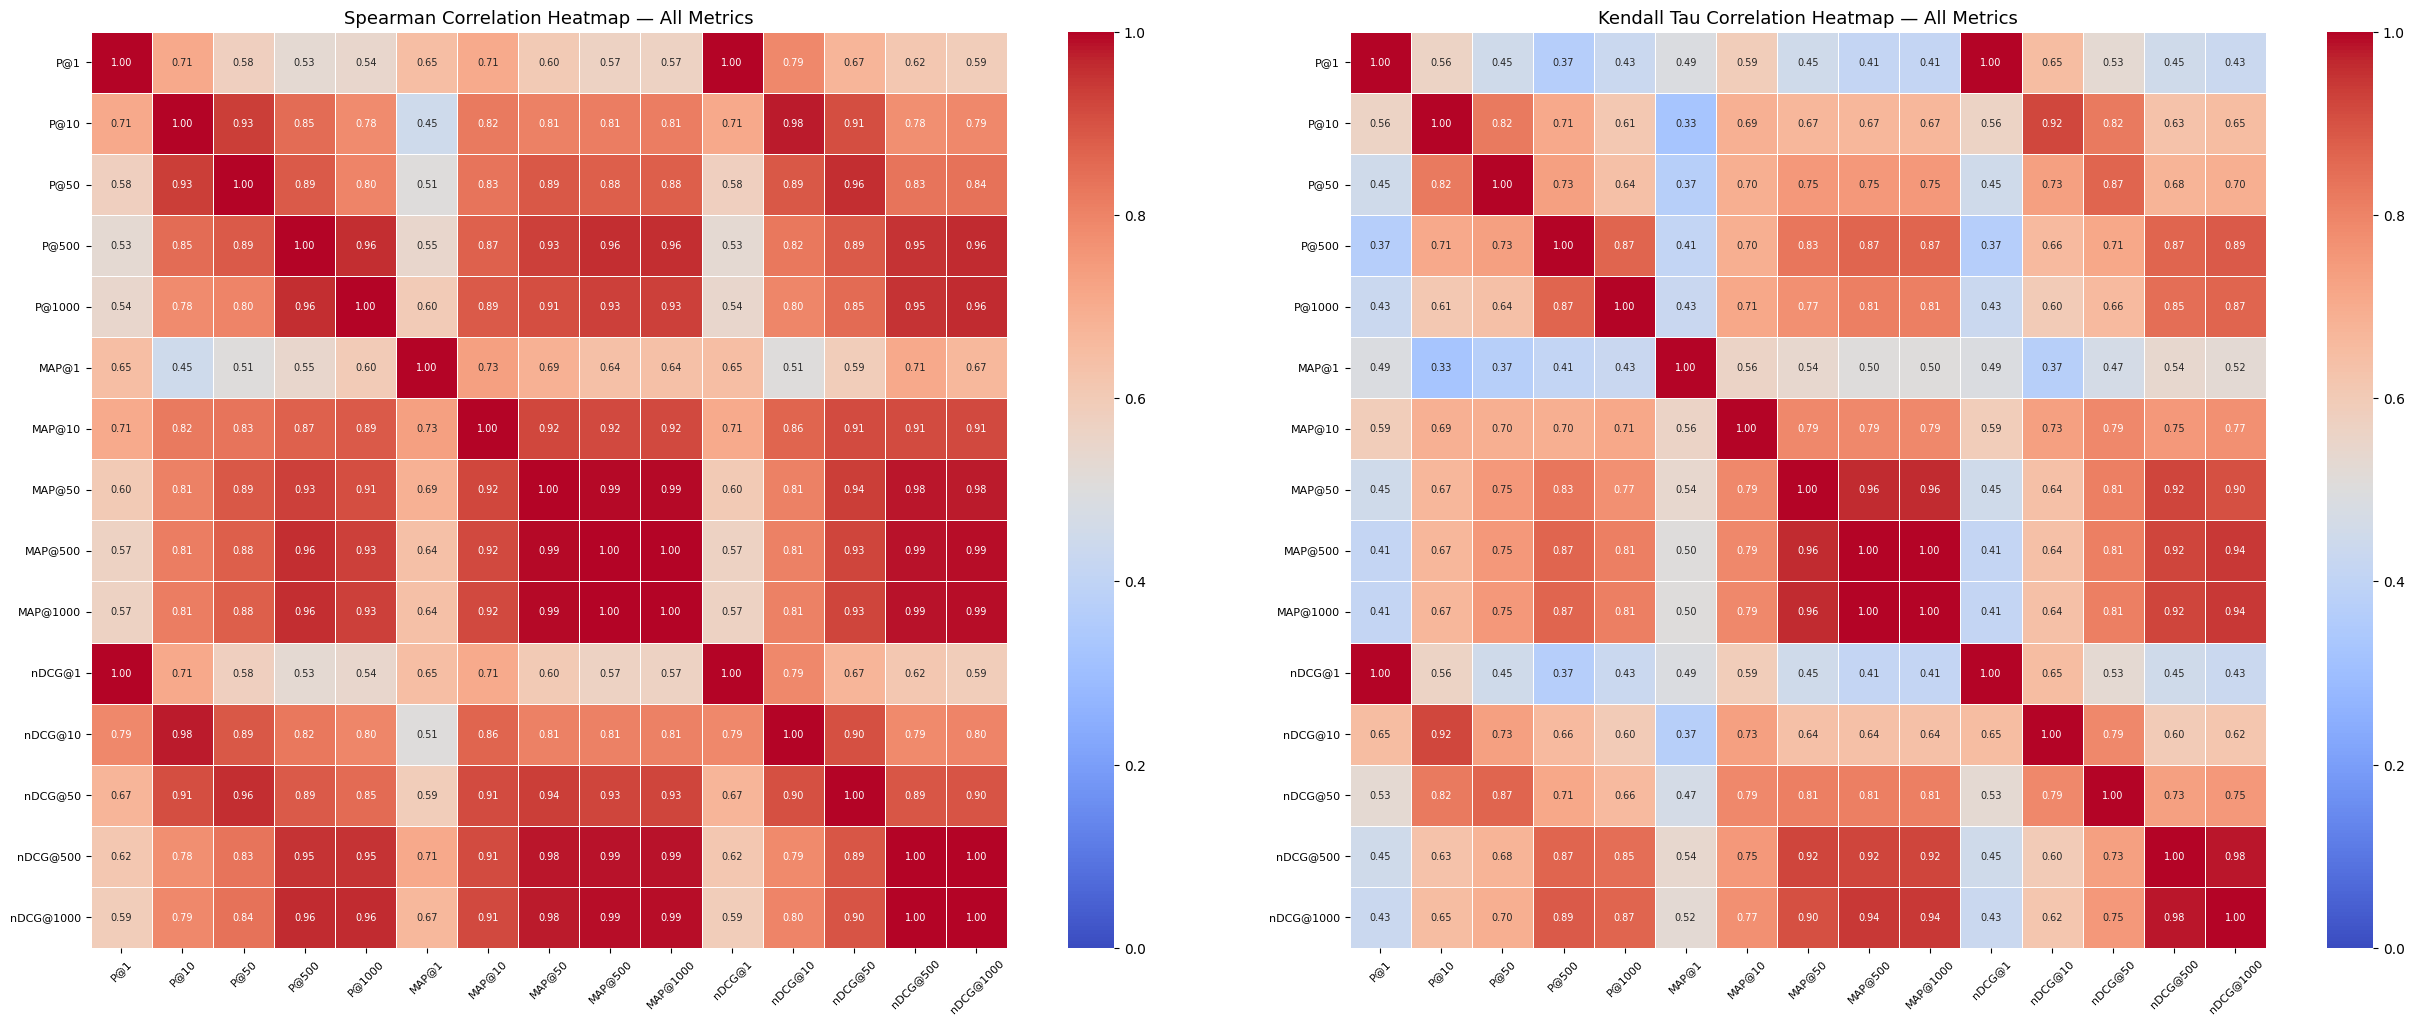

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(26, 10))
for ax, matrix, method in zip(axes,
                               [all_metric_corr_spearman, all_metric_corr_kendall],
                               ['Spearman', 'Kendall Tau']):
    sns.heatmap(matrix, annot=True, cmap='coolwarm',
                fmt='.2f', vmin=0, vmax=1,
                linewidths=0.5, ax=ax,
                annot_kws={'size': 7}, square=True)
    ax.set_title(f"{method} Correlation Heatmap — All Metrics", fontsize=13)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

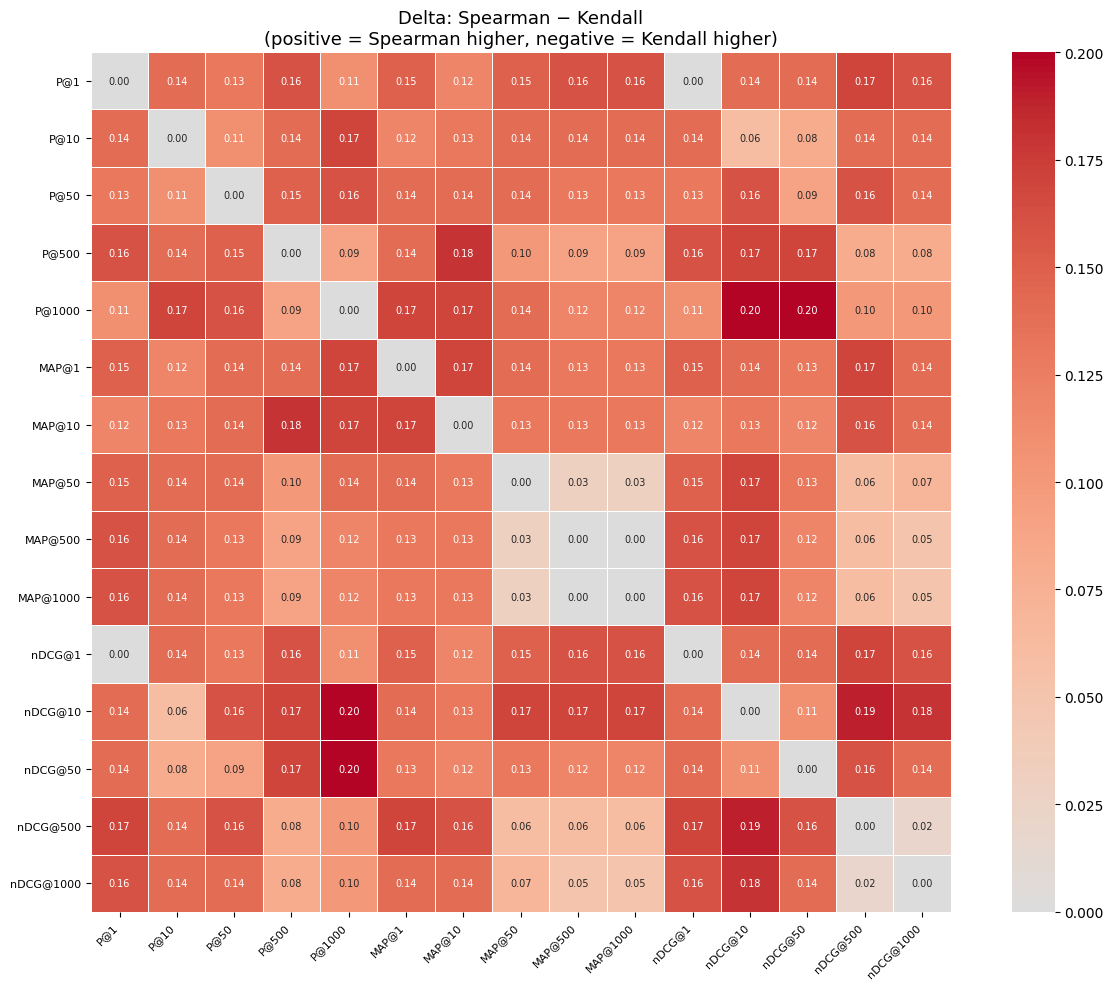

In [67]:
delta_matrix = (all_metric_corr_spearman - all_metric_corr_kendall).round(2)
plt.figure(figsize=(13, 10))
sns.heatmap(delta_matrix, annot=True, cmap='coolwarm',
            fmt='.2f', center=0, linewidths=0.5,
            annot_kws={'size': 7}, square=True)
plt.title("Delta: Spearman − Kendall\n"
          "(positive = Spearman higher, negative = Kendall higher)", fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()